# EDA

In [ ]:
import pandas as pd

url_train = "https://docs.google.com/spreadsheets/d/1oRwnEwAK5HcG2p4k0wFyeHEIhUJNdPuVquG2BzZYml4/export?format=csv&gid=7554799"
df_train = pd.read_csv(url_train)
df_train.head()

,X.1,X.2,X.3,X.4,X.5,X.6,X.7,X.8,X.9,X.10,...,X.19,X.20,X.21,X.22,X.23,X.24,X.25,X.26,X.27,X.28
0,47839,14/07/2016,14/07/2017,14/07/2018,23/02/1962,08/07/1985,1,2,1,1,...,3,0,0,2002,60,1686,10776.15,5,D,1045
1,21188,18/07/2015,18/07/2016,18/07/2017,05/04/1986,15/02/2005,0,2,1,1,...,3,0,0,2008,112,1598,21400.00,3,D,1090
2,21426,22/09/2017,22/09/2018,22/09/2019,31/03/1991,20/01/2013,1,4,1,2,...,3,0,0,2008,150,1995,31200.00,4,D,1415
3,4755,12/07/2016,12/07/2016,12/07/2017,25/10/1972,12/12/1991,0,1,1,1,...,2,0,0,1989,60,1769,12068.32,4,D,970
4,27707,30/01/2014,30/01/2016,30/01/2017,26/07/1974,24/03/1993,0,3,1,1,...,3,0,0,2003,100,1870,24160.00,5,D,1315


In [ ]:
url_test = "https://docs.google.com/spreadsheets/d/14G5cpcPY9Mu4-LXlY-BjngPg1DU8Xsa8pPhjNTeoIxk/export?format=csv&gid=1566012800"
df_test = pd.read_csv(url_test)
df_test.head()

,X.2,X.3,X.4,X.5,X.6,X.7,X.8,X.9,X.10,X.11,...,X.19,X.20,X.21,X.22,X.23,X.24,X.25,X.26,X.27,X.28
0,13/08/2015,13/08/2016,13/08/2017,31/10/1970,20/12/2002,0,2,1,1,1,...,3,1,0,2000,80,1686,16427.04,5,D,1205
1,16/09/2011,16/09/2018,16/09/2019,28/09/1968,10/11/1986,0,21,2,2,1,...,2,0,0,2011,120,2198,34425.00,5,D,1925
2,14/01/2014,14/01/2018,14/01/2019,01/01/1977,21/01/2005,0,5,1,1,1,...,3,0,0,2007,90,2497,29264.60,4,D,1230
3,05/07/2015,05/07/2018,05/07/2019,04/07/1964,29/04/1996,1,4,1,1,1,...,3,0,0,2007,115,1753,21245.00,5,D,1416
4,08/11/2018,08/11/2018,08/11/2019,10/07/1978,07/06/1997,1,1,2,2,1,...,1,1,0,2018,12,125,3389.00,0,P,137


In [ ]:
import numpy as np
df_train['LC']   = np.where(df_train['X.16'] > 0, df_train['X.15'] / df_train['X.16'], 0.0)
df_train['HALC'] = np.where(df_train['X.16'] > 0, (df_train['X.15'] / df_train['X.16']) * df_train['X.18'], 0.0)
df_train['CS']   = (df_train['X.16'] > 0).astype(int)

print('=== Target Summary ===')
print(f'Total policies:          {len(df_train):,}')
print(f'Policies WITH a claim:   {df_train["CS"].sum():,}  ({df_train["CS"].mean()*100:.1f}%)')
print(f'Policies with NO claim:  {(df_train["CS"]==0).sum():,}  ({(df_train["CS"]==0).mean()*100:.1f}%)')
print()
print('LC (nonzero rows only):')
print(df_train.loc[df_train['LC']>0, 'LC'].describe().round(2))
print()
print('HALC (nonzero rows only):')
print(df_train.loc[df_train['HALC']>0, 'HALC'].describe().round(2))

=== Target Summary ===
Total policies:          39,928
Policies WITH a claim:   4,453  (11.2%)
Policies with NO claim:  35,475  (88.8%)

LC (nonzero rows only):
count     4453.00
mean       573.25
std       1436.46
min          4.01
25%         70.26
50%        181.71
75%        604.96
max      35191.03
Name: LC, dtype: float64

HALC (nonzero rows only):
count     4438.00
mean      1044.59
std       2964.22
min          3.48
25%        111.67
50%        307.69
75%        995.80
max      78131.46
Name: HALC, dtype: float64


# Data Visualizations and Distrubution Analysis

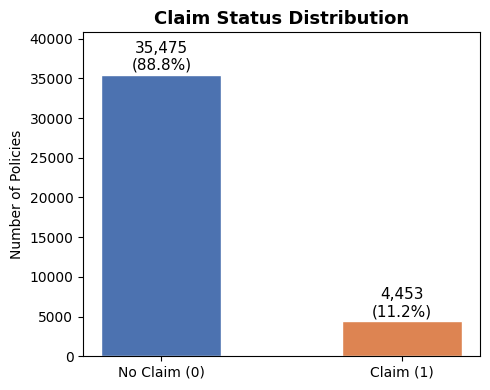

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_train['CS'].value_counts().sort_index()
bars = ax.bar(['No Claim (0)', 'Claim (1)'], counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(df_train)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Claim Status Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Policies')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

Total observations: 39928
No-claim observations: 35475
Claim observations: 4453

Percentage with no claims: 88.85 %
Percentage with claims: 11.15 %

Comparison of Key Variables:


,No_Claims_Mean,Claims_Mean,No_Claims_Median,Claims_Median
X.8,5.917378,4.365821,4.00,3.00
X.9,1.466808,1.858298,1.00,1.00
X.14,317.282699,351.892592,293.53,318.89
X.23,93.119154,99.971929,90.00,100.00
X.25,18439.442967,20311.216324,17633.70,19075.00


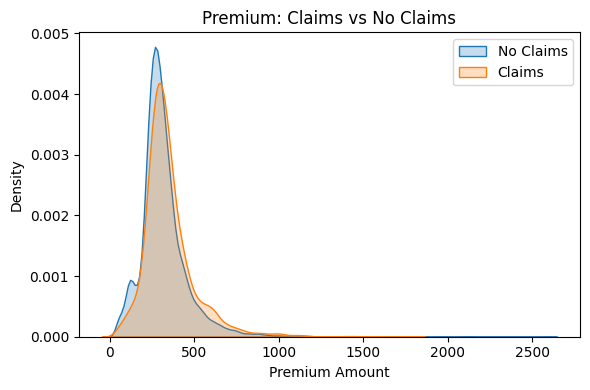

In [ ]:
#Compare characteristics of claim and no claim

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Split dataset
df_zero = df_train[df_train['CS'] == 0]
df_nonzero = df_train[df_train['CS'] == 1]

print("Total observations:", len(df_train))
print("No-claim observations:", len(df_zero))
print("Claim observations:", len(df_nonzero))

print("\nPercentage with no claims:", round(len(df_zero)/len(df_train)*100, 2), "%")
print("Percentage with claims:", round(len(df_nonzero)/len(df_train)*100, 2), "%")

key_vars = ['X.8', 'X.9', 'X.14', 'X.23', 'X.25']

comparison = pd.DataFrame({
    'No_Claims_Mean': df_zero[key_vars].mean(),
    'Claims_Mean': df_nonzero[key_vars].mean(),
    'No_Claims_Median': df_zero[key_vars].median(),
    'Claims_Median': df_nonzero[key_vars].median()
})

print("\nComparison of Key Variables:")
display(comparison)


plt.figure(figsize=(6,4))

sns.kdeplot(df_zero['X.14'], label='No Claims', fill=True)
sns.kdeplot(df_nonzero['X.14'], label='Claims', fill=True)

plt.title('Premium: Claims vs No Claims')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

#Claim and no claim individuals show the same type of distribution in how premium is spread.

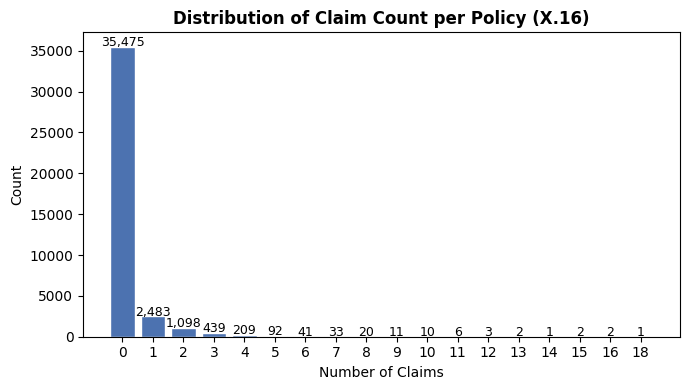

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_train['X.16'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color='#4C72B0', edgecolor='white')
ax.set_title('Distribution of Claim Count per Policy (X.16)', fontweight='bold')
ax.set_xlabel('Number of Claims')
ax.set_ylabel('Count')
for i, (x, v) in enumerate(zip(vc.index, vc.values)):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

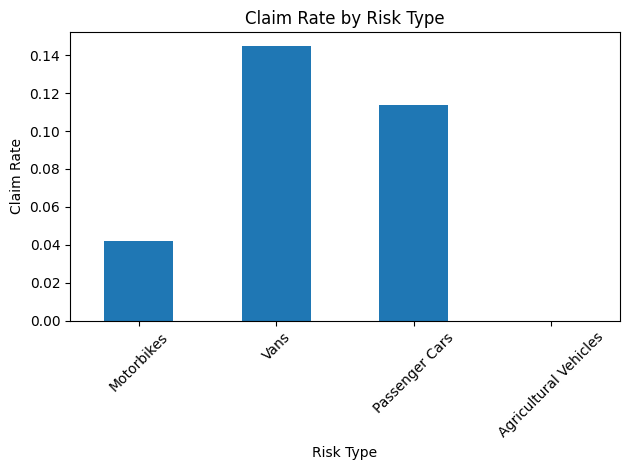

,Claim_Rate,Avg_Claim_Cost,Avg_Claim_Count
X.20,,,
0,0.107689,105.056329,0.197963
1,0.121781,124.876887,0.238962


In [ ]:
#Exploring categorical features impact

#Analyze risk of claim by risk type
#include risk labels
risk_type_mapping = {
    1: "Motorbikes",
    2: "Vans",
    3: "Passenger Cars",
    4: "Agricultural Vehicles"
}

risk_analysis = df_train.groupby('X.19').agg({
    'CS': 'mean',        #claim likelihood
    'X.15': 'mean',      #avg claim cost
    'X.16': 'mean'       #avg claim frequency
}).rename(columns={
    'CS': 'Claim_Rate',
    'X.15': 'Avg_Claim_Cost',
    'X.16': 'Avg_Claim_Count'
})

risk_analysis.index = risk_analysis.index.map(risk_type_mapping)
risk_analysis

#Bar plot for claim rate by risk type
risk_analysis['Claim_Rate'].plot(kind='bar')

plt.title('Claim Rate by Risk Type')
plt.ylabel('Claim Rate')
plt.xlabel('Risk Type')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#Urban vs Rural claims
urban_analysis = df_train.groupby('X.20').agg({
    'CS': 'mean',
    'X.15': 'mean',
    'X.16': 'mean'
}).rename(columns={
    'CS': 'Claim_Rate',
    'X.15': 'Avg_Claim_Cost',
    'X.16': 'Avg_Claim_Count'
})

urban_analysis

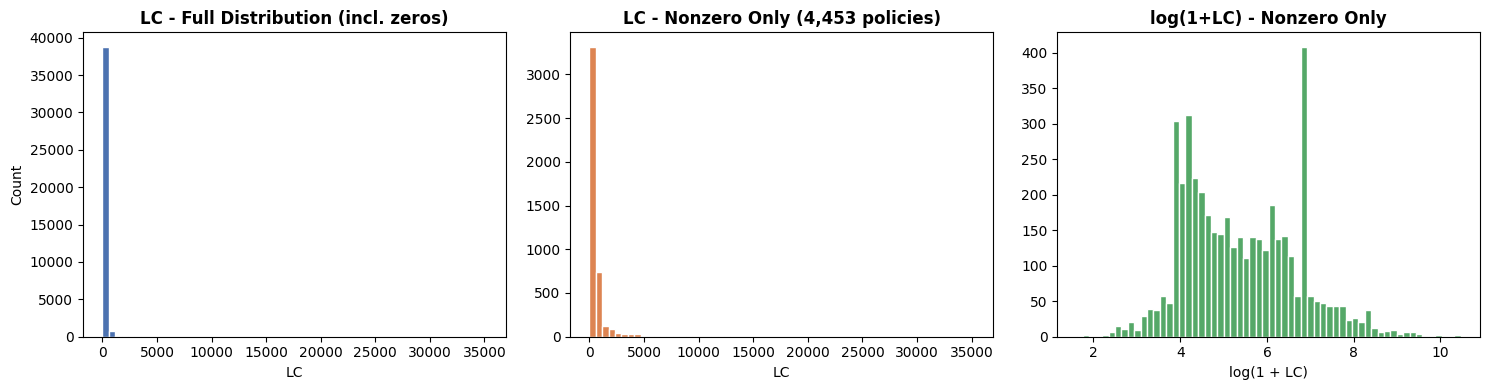

Skewness of nonzero LC:    10.37
Skewness of log(1+LC):     0.42
% policies with LC > 0:    11.2%


In [ ]:
lc_pos = df_train.loc[df_train['LC'] > 0, 'LC']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_train['LC'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('LC - Full Distribution (incl. zeros)', fontweight='bold')
axes[0].set_xlabel('LC')
axes[0].set_ylabel('Count')

axes[1].hist(lc_pos, bins=60, color='#DD8452', edgecolor='white')
axes[1].set_title('LC - Nonzero Only (4,453 policies)', fontweight='bold')
axes[1].set_xlabel('LC')

axes[2].hist(np.log1p(lc_pos), bins=60, color='#55A868', edgecolor='white')
axes[2].set_title('log(1+LC) - Nonzero Only', fontweight='bold')
axes[2].set_xlabel('log(1 + LC)')

plt.tight_layout()
plt.show()

print(f'Skewness of nonzero LC:    {lc_pos.skew():.2f}')
print(f'Skewness of log(1+LC):     {np.log1p(lc_pos).skew():.2f}')
print(f'% policies with LC > 0:    {(df_train["LC"]>0).mean()*100:.1f}%')

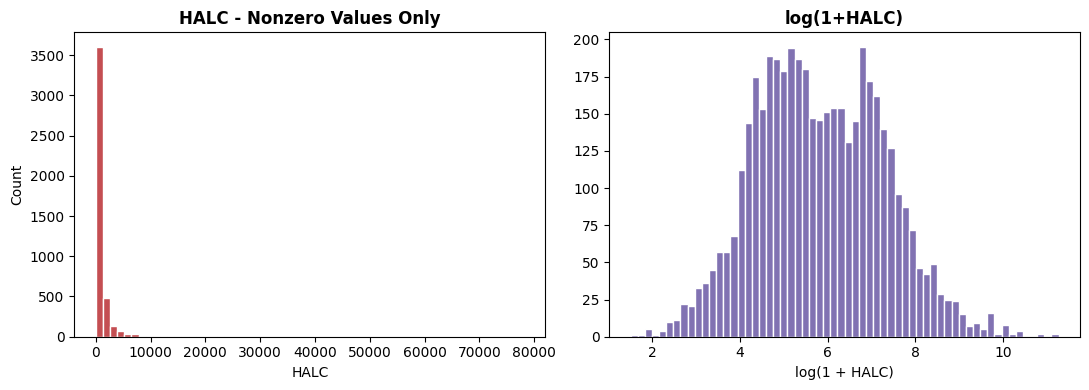

HALC skewness (raw): 12.35
HALC skewness (log): 0.19


In [ ]:
halc_pos = df_train.loc[df_train['HALC'] > 0, 'HALC']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(halc_pos, bins=60, color='#C44E52', edgecolor='white')
axes[0].set_title('HALC - Nonzero Values Only', fontweight='bold')
axes[0].set_xlabel('HALC')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(halc_pos), bins=60, color='#8172B2', edgecolor='white')
axes[1].set_title('log(1+HALC)', fontweight='bold')
axes[1].set_xlabel('log(1 + HALC)')
plt.tight_layout()
plt.show()

print(f'HALC skewness (raw): {halc_pos.skew():.2f}')
print(f'HALC skewness (log): {np.log1p(halc_pos).skew():.2f}')

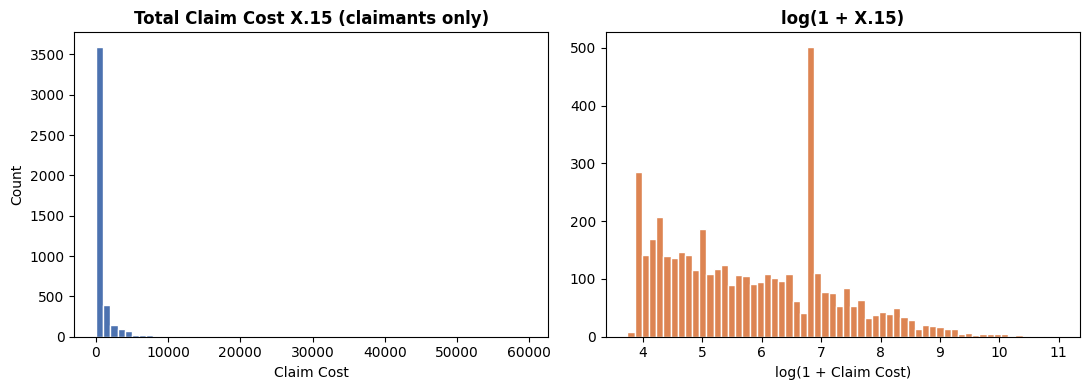

Skewness raw: 9.45  |  after log: 0.50


In [ ]:
x15_pos = df_train.loc[df_train['X.16'] > 0, 'X.15']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(x15_pos, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Total Claim Cost X.15 (claimants only)', fontweight='bold')
axes[0].set_xlabel('Claim Cost')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(x15_pos), bins=60, color='#DD8452', edgecolor='white')
axes[1].set_title('log(1 + X.15)', fontweight='bold')
axes[1].set_xlabel('log(1 + Claim Cost)')
plt.tight_layout()
plt.show()

print(f'Skewness raw: {x15_pos.skew():.2f}  |  after log: {np.log1p(x15_pos).skew():.2f}')

In [ ]:
import pandas as pd
import numpy as np

# Step 1a: Parse date columns
date_cols = ['X.2', 'X.3', 'X.4', 'X.5', 'X.6']
for col in date_cols:
  df_train[col] = pd.to_datetime(df_train[col], dayfirst=True, errors='coerce')

# Step 1b: Quick audit
print("Shape:", df_train.shape)
print("\nDtypes:")
print(df_train.dtypes)

print("\nMissing values:")
nulls = df_train.isnull().sum()
print(nulls[nulls > 0])

print("\nBasic numeric summary:")
display(df_train.describe(include=[np.number]).T)

print("\nBasic categorical summary:")
cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21', 'X.27']
existing_cat_cols = [c for c in cat_cols if c in df_train.columns]
for col in existing_cat_cols:
    print(f"\n{col} value counts:")
    print(df_train[col].value_counts(dropna=False))

Shape: (39928, 31)

Dtypes:
X.1              int64
X.2     datetime64[ns]
X.3     datetime64[ns]
X.4     datetime64[ns]
X.5     datetime64[ns]
X.6     datetime64[ns]
X.7              int64
X.8              int64
X.9              int64
X.10             int64
X.11             int64
X.12             int64
X.13             int64
X.14           float64
X.15           float64
X.16             int64
X.17             int64
X.18           float64
X.19             int64
X.20             int64
X.21             int64
X.22             int64
X.23             int64
X.24             int64
X.25           float64
X.26             int64
X.27            object
X.28             int64
LC             float64
HALC           float64
CS               int64
dtype: object

Missing values:
X.27    453
dtype: int64

Basic numeric summary:


,count,mean,std,min,25%,50%,75%,max
X.1,39928.0,26783.389226,15435.273012,1.00,13406.00,26796.000,40096.25,53502.00
X.7,39928.0,0.476408,0.499449,0.00,0.00,0.000,1.00,1.00
X.8,39928.0,5.744340,5.861058,1.00,2.00,4.000,7.00,40.00
X.9,39928.0,1.510469,1.034381,1.00,1.00,1.000,2.00,17.00
X.10,39928.0,1.856417,1.224983,1.00,1.00,2.000,2.00,17.00
X.11,39928.0,1.056151,0.247921,1.00,1.00,1.000,1.00,4.00
X.12,39928.0,0.382664,0.555401,0.00,0.00,0.000,1.00,7.00
X.13,39928.0,0.339486,0.473541,0.00,0.00,0.000,1.00,1.00
X.14,39928.0,321.142593,143.949016,40.18,243.71,296.325,368.53,2596.77
X.15,39928.0,110.453271,910.792191,0.00,0.00,0.000,0.00,59656.65



Basic categorical summary:

X.7 value counts:
X.7
0    20906
1    19022
Name: count, dtype: int64

X.13 value counts:
X.13
0    26373
1    13555
Name: count, dtype: int64

X.19 value counts:
X.19
3    31706
2     4949
1     3014
4      259
Name: count, dtype: int64

X.20 value counts:
X.20
0    29056
1    10872
Name: count, dtype: int64

X.21 value counts:
X.21
0    34804
1     5124
Name: count, dtype: int64

X.27 value counts:
X.27
D      24800
P      14675
NaN      453
Name: count, dtype: int64


In [ ]:
bad = df_train['X.3'] < df_train['X.2']
print(f'Rows where last renewal (X.3) < policy start (X.2): {bad.sum()}')

print(f'Rows with X.23 (horsepower) = 0: {(df_train["X.23"]==0).sum()}')


Rows where last renewal (X.3) < policy start (X.2): 35
Rows with X.23 (horsepower) = 0: 453


In [ ]:
# ---- Training-derived constants ----
# These must come from df_train so we don't leak test info into preprocessing

hp_median_train = df_train.loc[df_train['X.23'] > 0, 'X.23'].median()
x27_mode_train  = df_train['X.27'].mode()[0]           # should be 'D' if run before encoding
ref_date        = pd.to_datetime(df_train['X.3'].max()) # same ref_date used for train features

print(f"HP median (from train):  {hp_median_train}")
print(f"X.27 mode (from train): {x27_mode_train}")
print(f"Reference date:         {ref_date.date()}")

HP median (from train):  92.0
X.27 mode (from train): D
Reference date:         2018-11-30


In [ ]:
#replace X.3 with X.2 for these rows before computing time_since_last_renewal, so the result becomes 0 instead of negative
df_train.loc[df_train['X.3'] < df_train['X.2'], 'X.3'] = df_train.loc[df_train['X.3'] < df_train['X.2'], 'X.2']

#Replace 0 horsepower values with median
hp_median = df_train.loc[df_train['X.23'] > 0, 'X.23'].median()
df_train['X.23'] = df_train['X.23'].replace(0, hp_median)

# Step 2a: Fix missing values in X.27 (fuel type)
# Since it's categorical (P/D), fill with most common value (mode)
df_train['X.27'] = df_train['X.27'].fillna(df_train['X.27'].mode()[0])

# Step 2b: Convert X.27 to numeric (binary encoding)
# P = 1 (Petrol), D = 0 (Diesel)
df_train['X.27'] = df_train['X.27'].map({'P': 1, 'D': 0})

# Step 2c: Convert categorical integer variables to category type (helps models later)
cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']
for col in cat_cols:
    df_train[col] = df_train[col].astype('category')

In [ ]:
# Step 3a: Create reference date (use last observed contract date as proxy)
# for any given policy row, the snapshot date must fall between X.3 and X.4. So the snapshot date is somewhere in the window
# [X.3.max(), X.4.min_of_2019_policies].
# Using X.3.max() = 2018-11-30 is the safest and most conservative choice — it's the latest date we can confirm events actually
# occurred up to, with no assumptions about the future.
# If instead you used X.4.max() = 2019-11-30, you'd be pretending the snapshot was taken a full year after the last observed event,
# which would artificially add ~1 year to every driver age, license experience, and policy tenure.
ref_date = df_train['X.3'].max()

# Step 3b: Age of policyholder
df_train['driver_age'] = (ref_date - df_train['X.5']).dt.days / 365.25

# Step 3c: Driving experience
df_train['license_years'] = (ref_date - df_train['X.6']).dt.days / 365.25

#Age they got their license
df_train['age_at_license'] = (df_train['X.6'] - df_train['X.5']).dt.days / 365.25

df_train['vehicle_age'] = ref_date.year - df_train['X.22']

# Step 3d: Policy tenure (how long they've been with company)
df_train['policy_tenure'] = (ref_date - df_train['X.2']).dt.days / 365.25

# Step 3e: Time since last renewal
df_train['time_since_last_renewal'] = (ref_date - df_train['X.3']).dt.days / 365.25

# Step 3f: Time until next renewal (can capture renewal cycles / risk timing)
df_train['time_until_next_renewal'] = (df_train['X.4'] - ref_date).dt.days / 365.25

# Step 3g: Drop raw date columns
df_train.drop(columns=['X.2', 'X.3', 'X.4', 'X.5', 'X.6', 'X.22'], inplace=True)

# Quick sanity check
# print(df_train[['driver_age', 'license_years', 'age_at_license', 'policy_tenure', 'vehicle_age',
#                 'time_since_last_renewal', 'time_until_next_renewal']].describe())

In [ ]:
print(f'Driver age range: {df_train['driver_age'].min():.1f} to {df_train['driver_age'].max():.1f} years')
print(f'Drivers over 85:  {(df_train['driver_age'] > 85).sum()} rows')

Driver age range: 18.1 to 100.7 years
Drivers over 85:  7 rows


In [ ]:
df_train['driver_age'] = df_train['driver_age'].clip(upper=85)

In [ ]:
# Step 4a: Fix time until next renewal (relative to last renewal instead of global ref)

# df_train['time_until_next_renewal'] = (
#     (df_train['time_since_last_renewal'] +
#      ((df_train['policy_tenure'] - df_train['time_since_last_renewal'])))
# ) -> This just gives us policy_tenure that we've already calculated

# Step 4b: Alternatively (cleaner + better): use contract cycle length
# df_train['contract_cycle_length'] = (
#     df_train['time_since_last_renewal'] +
#     abs(df_train['time_until_next_renewal'])
# ) -> Not necessary as most of them are close to 1 and provide no information



# Step 4c: Drop the broken feature
df_train.drop(columns=['time_until_next_renewal'], inplace=True)

# # Check
# print(df_train[['time_since_last_renewal', 'contract_cycle_length']].describe())

In [ ]:
# Step 5a: Log transform highly skewed variables
# Add small constant to avoid log(0)

# No need to log transform as XGBoost with Tweedie loss handles skewed, zero-inflated data natively.
# That's the whole point of using Tweedie loss — it was designed for exactly this distribution.
#Also, X.15 and X.18 are target columns. We should not transforming them as feature.
# df_train['log_X15'] = np.log1p(df_train['X.15'])
# df_train['log_X18'] = np.log1p(df_train['X.18'])
# df_train['log_X25'] = np.log1p(df_train['X.25'])

# Step 5b: Cap extreme outliers (99th percentile)
# Outlier capping — also unnecessary for XGBoost
# Tree-based models split on thresholds, so a value of 220,000 vs 150,000 only matters insofar as it affects
# where a split is placed. Extreme values don't distort trees the way they distort linear regression or neural networks.
# Capping at the 99th percentile would actually throw away real signal — a 220k vehicle genuinely behaves differently from a 22k vehicle.
# For a GLM baseline model you might reconsider this, but for XGBoost skip it.
# def cap_outliers(col):
#     upper = df_train[col].quantile(0.99)
#     df_train[col] = np.where(df_train[col] > upper, upper, df_train[col])

# # Apply to key skewed variables
# for col in ['X.15', 'X.18', 'X.25', 'X.23', 'X.24']:
#     cap_outliers(col)

# # Step 5c: Check results
# print("After transformation:\n")
# print(df_train[['X.15', 'log_X15', 'X.18', 'log_X18']].describe())

In [ ]:
#Shown visualization at the top
# Step 6a: Claim Status (binary classification target)
# df_train['CS'] = np.where(df_train['X.16'] > 0, 1, 0)

# # Step 6b: Loss Cost (LC)
# df_train['LC'] = np.where(
#     df_train['X.16'] > 0,
#     df_train['X.15'] / df_train['X.16'],
#     0
# )

# # Step 6c: Historically Adjusted Loss Cost (HALC)
# df_train['HALC'] = np.where(
#     df_train['X.16'] > 0,
#     (df_train['X.15'] / df_train['X.16']) * df_train['X.18'],
#     0
# )

# # Step 6d: Check distributions
# print("CS distribution:\n", df_train['CS'].value_counts(normalize=True))
# print("\nLC summary:\n", df_train['LC'].describe())
# print("\nHALC summary:\n", df_train['HALC'].describe())

Data Quality:

- Claim distribution is highly skewed
- Majority of policies have zero claims
- Certain segments show higher claim likelihood
- Extreme losses dominate averages

1. Loaded and Inspected the Data
Checked dataset shape, types, and missing values
Found:
~40,000 rows
Almost no missing data (only in X.27)
Identified which variables are numeric vs categorical


2. Handled Missing Values
Only issue: X.27 (fuel type) had missing values
Fixed by:
Filling with the most common value (mode)
Converting:
Petrol (P) → 1
Diesel (D) → 0

3. Converted Categorical Variables
Marked variables like:
X.7 (channel)
X.13 (payment type)
X.19 (vehicle type)
etc.
Converted them to categorical format so models treat them properly

4. Created Useful Features from Dates (VERY IMPORTANT)

  Raw dates don’t help models much, so you created meaningful variables:

  Age → how old the driver is
  Driving experience → years since license
  Policy tenure → how long they’ve been a customer
  Time since last renewal → behavior signal
  Contract cycle length → renewal pattern
  Removed the original date columns

5. Handled Skewed Data (Key for Insurance)

Insurance data has extreme values (few very large claims)
Creating log-transformed variables:
log_X15 (claims cost)
log_X18 (claim ratio)
log_X25 (vehicle value)
Capping extreme outliers (top 1%) to reduce distortion

6. Created Target Variables (Core of the Project)

You built the main outputs:

CS (Claim Status)
→ 1 if claim exists, 0 otherwise
LC (Loss Cost)
→ cost per claim
HALC (Historically Adjusted Loss Cost)
→ LC adjusted by historical risk

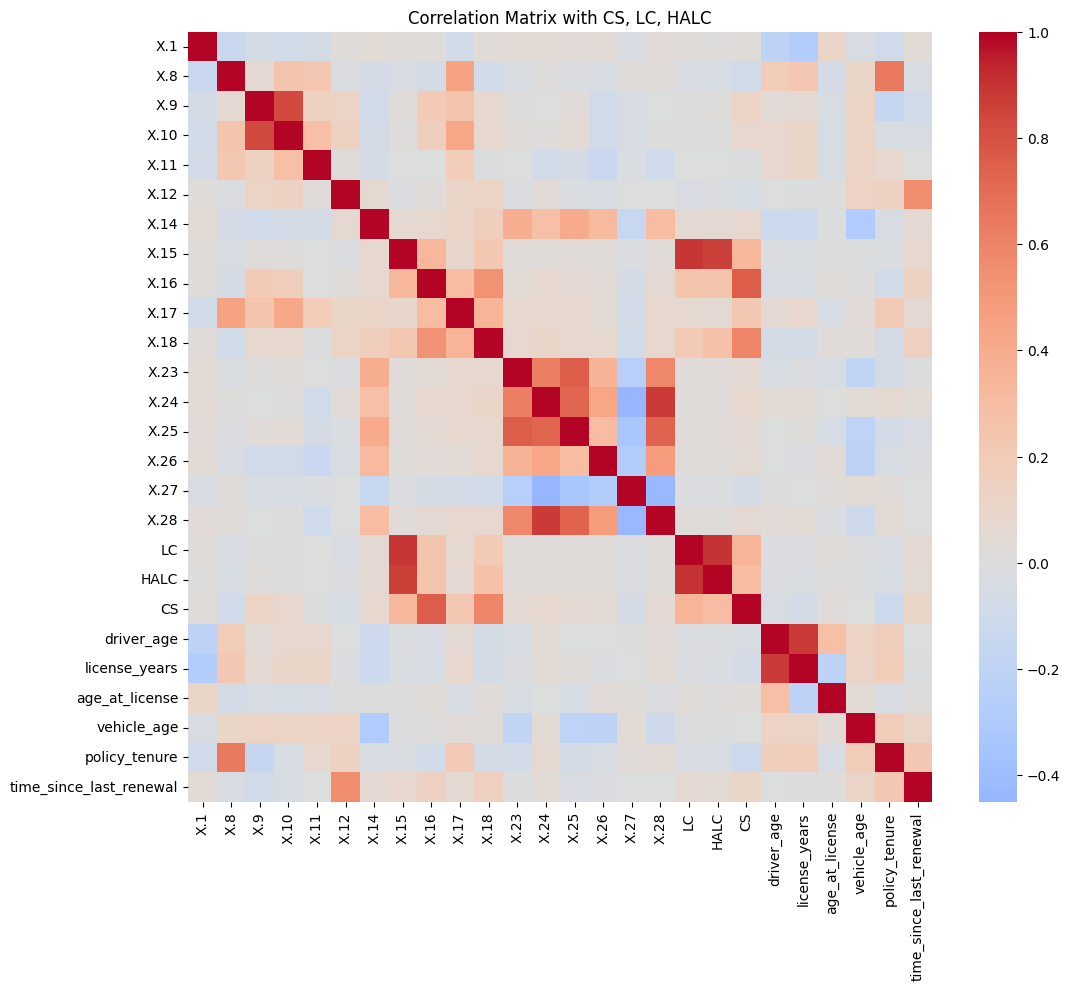

,CS,LC,HALC
HALC,0.314726,0.900949,1.000000
LC,0.352110,1.000000,0.900949
X.15,0.342294,0.887154,0.860957
CS,1.000000,0.352110,0.314726
X.18,0.597130,0.205354,0.267499
X.16,0.761880,0.244519,0.247752
X.17,0.227957,0.066098,0.061249
X.14,0.075685,0.057127,0.055165
time_since_last_renewal,0.108419,0.064715,0.049488
X.25,0.063892,0.030551,0.029651


In [ ]:
#Map correlation of numeric columns to outputs
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Select the numeric columns
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df_train[numeric_cols]

#Build correlation matrix
corr_matrix = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix with CS, LC, HALC')
plt.show()

# Correlation with updated targets
target_corr = corr_matrix[['CS', 'LC', 'HALC']].sort_values(by='HALC', ascending=False)
target_corr


In [ ]:
df_train.drop(columns=['X.1', 'X.15', 'X.16', 'X.17', 'X.18'], inplace=True)
print(df_train.columns.tolist())
print(df_train.shape)

['X.7', 'X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28', 'LC', 'HALC', 'CS', 'driver_age', 'license_years', 'age_at_license', 'vehicle_age', 'policy_tenure', 'time_since_last_renewal']
(39928, 26)


In [ ]:
y_lc   = df_train['LC']
y_halc = df_train['HALC']
y_cs   = df_train['CS']

# Feature matrix
X = df_train.drop(columns=['LC', 'HALC', 'CS'])

print("Feature matrix shape:", X.shape)
print("Features:", X.columns.tolist())

Feature matrix shape: (39928, 23)
Features: ['X.7', 'X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28', 'driver_age', 'license_years', 'age_at_license', 'vehicle_age', 'policy_tenure', 'time_since_last_renewal']


## Step 2: Quick audit of test set

In [ ]:
print("Shape:", df_test.shape)
print("\nColumns:", df_test.columns.tolist())
print("\nMissing values:")
nulls = df_test.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "None")

Shape: (13310, 23)

Columns: ['X.2', 'X.3', 'X.4', 'X.5', 'X.6', 'X.7', 'X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.22', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28']

Missing values:
X.27    140
dtype: int64


## Step 3: Parse date columns

In [ ]:
date_cols = ['X.2', 'X.3', 'X.4', 'X.5', 'X.6']
for col in date_cols:
    df_test[col] = pd.to_datetime(df_test[col], dayfirst=True, errors='coerce')

print("Date columns parsed.")
print(df_test[date_cols].dtypes)

Date columns parsed.
X.2    datetime64[ns]
X.3    datetime64[ns]
X.4    datetime64[ns]
X.5    datetime64[ns]
X.6    datetime64[ns]
dtype: object


## Step 4: Fix data quality issues
Same logic as `df_train`.

In [ ]:
# 4a: Fix X.3 < X.2 (last renewal before policy start)
bad_dates = df_test['X.3'] < df_test['X.2']
print(f"Rows where X.3 < X.2: {bad_dates.sum()}")
df_test.loc[bad_dates, 'X.3'] = df_test.loc[bad_dates, 'X.2']

# 4b: Impute 0 horsepower with TRAINING median (not test median)
zero_hp = (df_test['X.23'] == 0).sum()
print(f"Rows with X.23 = 0: {zero_hp}")
df_test['X.23'] = df_test['X.23'].replace(0, hp_median_train)

# 4c: Fill missing X.27 with TRAINING mode, then encode P=1, D=0
df_test['X.27'] = df_test['X.27'].fillna(x27_mode_train)
df_test['X.27'] = df_test['X.27'].map({'P': 1, 'D': 0})

# 4d: Convert categorical columns to category type
cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']
for col in cat_cols:
    df_test[col] = df_test[col].astype('category')

print("\nData quality fixes applied.")

Rows where X.3 < X.2: 10
Rows with X.23 = 0: 140

Data quality fixes applied.


## Step 5: Feature engineering
Same engineered features as `df_train` (Cell 15), using the same `ref_date`.

In [ ]:
# 5a: Driver age
df_test['driver_age'] = (ref_date - df_test['X.5']).dt.days / 365.25

# 5b: Driving experience (years since license)
df_test['license_years'] = (ref_date - df_test['X.6']).dt.days / 365.25

# 5c: Age when they got their license
df_test['age_at_license'] = (df_test['X.6'] - df_test['X.5']).dt.days / 365.25

# 5d: Vehicle age
df_test['vehicle_age'] = ref_date.year - df_test['X.22']

# 5e: Policy tenure
df_test['policy_tenure'] = (ref_date - df_test['X.2']).dt.days / 365.25

# 5f: Time since last renewal
df_test['time_since_last_renewal'] = (ref_date - df_test['X.3']).dt.days / 365.25

# 5g: Clip driver_age at 85 (same as train)
df_test['driver_age'] = df_test['driver_age'].clip(upper=85)

print("Engineered features created.")
print(df_test[['driver_age', 'license_years', 'age_at_license',
               'vehicle_age', 'policy_tenure', 'time_since_last_renewal']].describe().round(2))

Engineered features created.
       driver_age  license_years  age_at_license  vehicle_age  policy_tenure  \
count    13310.00       13310.00        13310.00     13310.00       13310.00   
mean        48.13          25.44           22.69        13.20           3.78   
std         12.75          12.48            6.29         6.64           3.90   
min         18.15           0.03           18.00         0.00           0.00   
25%         38.25          15.05           18.57        10.00           1.11   
50%         47.84          24.42           20.00        13.00           2.68   
75%         57.29          34.66           24.30        17.00           4.76   
max         85.00          60.39           64.17        68.00          30.96   

       time_since_last_renewal  
count                 13310.00  
mean                      0.92  
std                       0.81  
min                       0.00  
25%                       0.33  
50%                       0.66  
75%                

## Step 6: Drop raw columns
Drop ID (X.1), raw date columns, and X.22 (replaced by vehicle_age).
X.15, X.16, X.17, X.18 are already absent in the test set.

In [ ]:
cols_to_drop = ['X.1', 'X.2', 'X.3', 'X.4', 'X.5', 'X.6', 'X.22']

# Only drop columns that exist in test
cols_to_drop = [c for c in cols_to_drop if c in df_test.columns]
df_test.drop(columns=cols_to_drop, inplace=True)

print("Final test set shape:", df_test.shape)
print("Columns:", df_test.columns.tolist())

Final test set shape: (13310, 23)
Columns: ['X.7', 'X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28', 'driver_age', 'license_years', 'age_at_license', 'vehicle_age', 'policy_tenure', 'time_since_last_renewal']


## Step 7: Verify train and test features match

In [ ]:
train_features = set(X.columns)
test_features  = set(df_test.columns)

missing_in_test = train_features - test_features
extra_in_test   = test_features - train_features

if not missing_in_test and not extra_in_test:
    print("All features match between train and test!")
else:
    if missing_in_test:
        print(f"Missing in test (need to fix): {missing_in_test}")
    if extra_in_test:
        print(f"Extra in test (consider dropping): {extra_in_test}")

print(f"\nTrain features ({len(train_features)}): {sorted(train_features)}")
print(f"Test features  ({len(test_features)}):  {sorted(test_features)}")

All features match between train and test!

Train features (23): ['X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28', 'X.7', 'X.8', 'X.9', 'age_at_license', 'driver_age', 'license_years', 'policy_tenure', 'time_since_last_renewal', 'vehicle_age']
Test features  (23):  ['X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20', 'X.21', 'X.23', 'X.24', 'X.25', 'X.26', 'X.27', 'X.28', 'X.7', 'X.8', 'X.9', 'age_at_license', 'driver_age', 'license_years', 'policy_tenure', 'time_since_last_renewal', 'vehicle_age']


# Additional Preprocessing and Feature Insights

1. One-hot encoding for categorical variables to support linear models.

2. Correlation analysis with target variables to identify key predictors.

3. Visualization of claim probability across driver age groups to uncover behavioral patterns.

### 1. One-Hot Encoding of Categorical Variables

Although categorical variables were previously converted into category types, most machine learning models (especially GLM and logistic regression) require purely numeric input.

Therefore, we apply one-hot encoding to transform categorical variables into binary indicator variables.

We intentionally create a separate encoded dataset to preserve the original dataset for models such as XGBoost that can handle categorical-like structures more efficiently.

We also align the training and test datasets to ensure they contain identical feature spaces, which is essential for consistent model predictions.

In [ ]:
# One-Hot Encoding

cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']

df_train_encoded = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# Align train and test to ensure identical feature sets
df_train_encoded, df_test_encoded = df_train_encoded.align(
    df_test_encoded, join='left', axis=1, fill_value=0
)

print("Encoded train shape:", df_train_encoded.shape)
print("Encoded test shape:", df_test_encoded.shape)

Encoded train shape: (39928, 28)
Encoded test shape: (13310, 28)


### 2. Correlation Analysis with Target Variables

Here we focus specifically on the correlation between input features and the target variables (CS, LC, and HALC).

This analysis is performed on the encoded dataset (after one-hot encoding). This ensures that all categorical variables are represented as numeric features, allowing us to properly capture their individual relationships with the target variables. In particular, one-hot encoding enables the model and analysis to distinguish between different categories within a variable, rather than treating them as a single grouped feature.

Importantly, we exclude the target variables themselves when identifying top features, as correlations among targets are not informative for model input selection.

This approach allows us to:
- Identify key predictors influencing claim likelihood and loss cost
- Support feature selection decisions
- Capture the effects of categorical variables at a more granular level
- Provide interpretable insights for business understanding

We analyze and visualize correlations for all three target variables (CS, LC, and HALC) using a consistent approach. This unified framework allows for direct comparison across targets, highlighting how different features influence the target variables.


In [ ]:
# Correlation with Targets
corr_matrix = df_train_encoded.corr()


# HALC Correlation
halc_corr = corr_matrix[['HALC']].drop(index=['CS','LC','HALC'])

top_halc = halc_corr.sort_values(by='HALC', ascending=False)

print("Top features correlated with HALC:")

display(top_halc.head(10))

Top features correlated with HALC:


,HALC
X.14,0.055165
X.13_1,0.050625
time_since_last_renewal,0.049488
X.25,0.029651
X.23,0.028076
X.24,0.024284
X.28,0.023990
X.26,0.018314
X.7_1,0.017871
X.19_3,0.014938


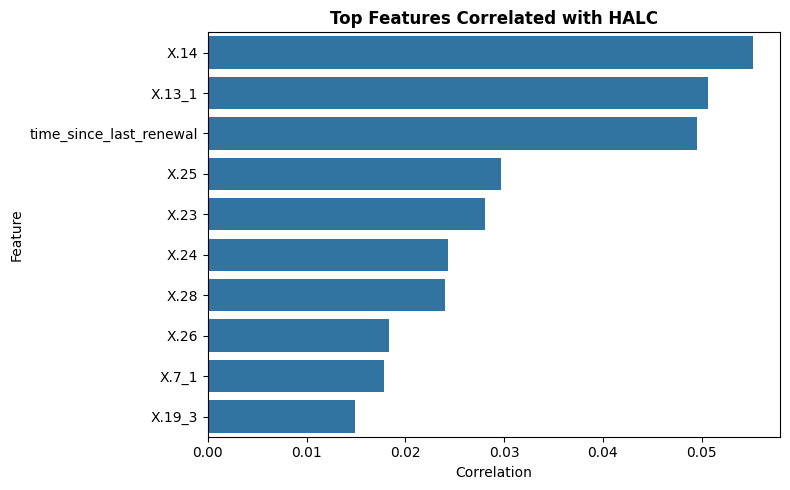

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features_halc = top_halc['HALC'].abs().head(10).index
plt.figure(figsize=(8,5))
sns.barplot(x=top_halc.loc[top_features_halc, 'HALC'], y=top_features_halc)
plt.title("Top Features Correlated with HALC", fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- HALC exhibits very similar patterns to LC, confirming that adjusted loss cost is largely driven by the same underlying factors as raw loss severity.

- Premium (X.14) is the strongest driver of HALC, reinforcing the idea that higher-risk customers are already priced accordingly.

- Vehicle-related variables (value, power, and technical characteristics) remain important, highlighting their role in determining the magnitude of losses.

- The consistency between LC and HALC suggests that the adjustment factor does not fundamentally change the key drivers, but refines the measurement of risk.



In [ ]:
# LC Correlation
lc_corr = corr_matrix[['LC']].drop(index=['CS','LC','HALC'])
top_lc = lc_corr.sort_values(by='LC', ascending=False)

print("\nTop features correlated with LC:")
display(top_lc.head(10))


Top features correlated with LC:


,LC
time_since_last_renewal,0.064715
X.14,0.057127
X.13_1,0.045416
X.25,0.030551
X.23,0.027653
X.28,0.023812
X.24,0.022629
X.26,0.018306
X.7_1,0.015872
age_at_license,0.014756


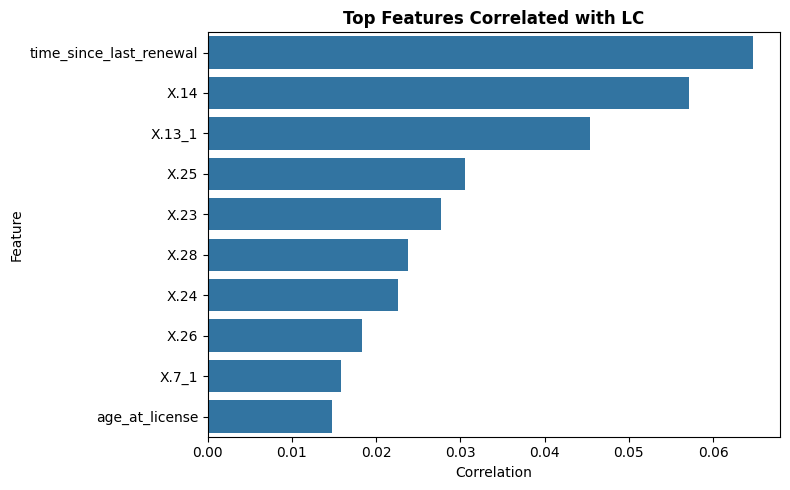

In [ ]:
top_features_lc = top_lc['LC'].abs().head(10).index
plt.figure(figsize=(8,5))
sns.barplot(x=top_lc.loc[top_features_lc, 'LC'], y=top_features_lc)
plt.title("Top Features Correlated with LC", fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- Loss cost is strongly influenced by time-related features, with time since last renewal showing the highest correlation, suggesting that loss severity varies over time.

- Vehicle characteristics such as value (X.25) and horsepower (X.23) are positively associated with loss cost, indicating that more expensive or powerful vehicles lead to higher claim costs.

- Premium (X.14) is positively correlated with loss cost, suggesting that pricing already reflects underlying risk differences among policyholders.

- Compared to CS, LC shows stronger and more structured relationships with input features, indicating that loss severity is more predictable than claim occurrence.

In [ ]:
# CS Correlation
cs_corr = corr_matrix[['CS']].drop(index=['CS','LC','HALC'])
top_cs = cs_corr.sort_values(by='CS', ascending=False)

print("\nTop features correlated with CS:")
display(top_cs.head(10))


Top features correlated with CS:


,CS
X.9,0.119140
X.13_1,0.108754
time_since_last_renewal,0.108419
X.10,0.086734
X.14,0.075685
X.24,0.072333
X.28,0.065327
X.25,0.063892
X.23,0.054967
X.26,0.051670


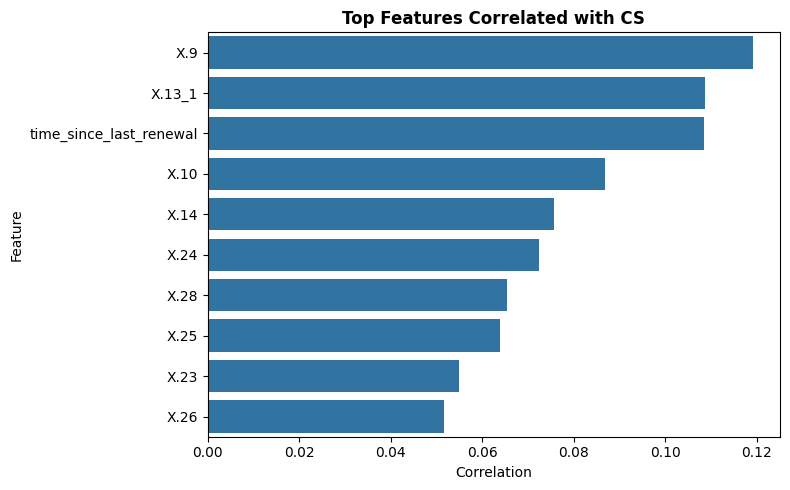

In [ ]:
top_features_cs = top_cs['CS'].abs().head(10).index
plt.figure(figsize=(8,5))
sns.barplot(x=top_cs.loc[top_features_cs, 'CS'], y=top_features_cs)
plt.title("Top Features Correlated with CS", fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- Customer activity is a key driver of claim occurrence. Variables such as the number of policies (X.9) and maximum policies (X.10) show the strongest associations, suggesting that more active customers are more likely to file claims due to higher exposure.

- Time-related features, particularly time since last renewal, are positively associated with claim probability, indicating that risk evolves over time and may follow temporal patterns.

- Payment-related variables (e.g., X.13) also influence claim likelihood, suggesting differences in behavior across customer segments.

- Overall correlations with CS are relatively weak, reflecting the binary nature of the variable and indicating that claim occurrence is difficult to capture using simple linear relationships.

### Overall Insights

- Different factors drive claim occurrence and loss severity. Customer behavior and exposure-related variables are more important for predicting whether a claim occurs (CS), while vehicle and financial characteristics primarily determine how large the loss will be (LC and HALC).

- The relatively low correlation values across all targets indicate that relationships are likely nonlinear and complex, supporting the use of advanced machine learning models rather than simple linear approaches.

- The distinction between frequency (CS) and severity (LC/HALC) suggests that modeling them separately (e.g., using a two-stage approach) may improve predictive performance.

### 3. Claim Probability by Driver Age

To better understand how risk varies across customer segments, we analyze how claim probability changes with driver age.

Instead of treating age as a continuous variable, we group drivers into business-relevant age intervals (e.g., 18–25, 25–35, etc.) and compute the average claim rate within each group. This approach improves interpretability and aligns with common insurance segmentation practices.

This analysis allows us to:
- Capture nonlinear relationships between age and risk
- Identify high-risk segments (e.g., younger drivers)
- Provide intuitive insights for pricing and customer segmentation

Such demographic-based analysis is particularly valuable in insurance, where customer characteristics play a central role in underwriting and pricing decisions.

/tmp/ipykernel_7844/2173974379.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_claim = df_train.groupby('age_bin')['CS'].mean()


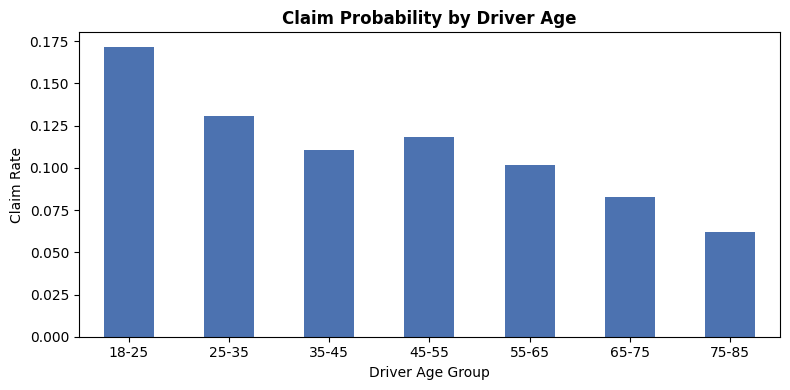

In [ ]:
# Claim Probability by Driver Age

# Create age bins
bins = [18, 25, 35, 45, 55, 65, 75, 85]
labels = ['18-25','25-35','35-45','45-55','55-65','65-75','75-85']
df_train['age_bin'] = pd.cut(df_train['driver_age'], bins=bins, labels=labels, include_lowest=True)
age_claim = df_train.groupby('age_bin')['CS'].mean()

plt.figure(figsize=(8,4))
age_claim.plot(kind='bar', color='#4C72B0')
plt.title("Claim Probability by Driver Age", fontweight='bold')
plt.ylabel("Claim Rate")
plt.xlabel("Driver Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

There is a clear inverse relationship between driver age and claim probability, indicating that younger drivers are significantly more likely to file claims than older drivers.

# Task 1: Predicting Loss Cost per Exposure Unit and Historically Ad-
justed Loss Cost

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_lc, y_val_lc = train_test_split(
    X, y_lc, test_size=0.2, random_state=42
)

_, _, y_train_halc, y_val_halc = train_test_split(
    X, y_halc, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Val size:  ", X_val.shape)

Train size: (31942, 23)
Val size:   (7986, 23)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

model_lc = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=20
)

model_lc.fit(
    X_train, y_train_lc,
    eval_set=[(X_val, y_val_lc)],
    verbose=125
)
print("Best iteration:", model_lc.best_iteration)
print("Best validation score:", model_lc.best_score)

[0]	validation_0-tweedie-nloglik@1.5:32.13655
[69]	validation_0-tweedie-nloglik@1.5:26.38674
Best iteration: 49
Best validation score: 26.258143346231442


In [ ]:
y_pred_lc = model_lc.predict(X_val)

mse_lc = mean_squared_error(y_val_lc, y_pred_lc)
rmse_lc = np.sqrt(mse_lc)

print(f"Validation MSE  (LC): {mse_lc:.4f}")
print(f"Validation RMSE (LC): {rmse_lc:.4f}")
print(f"Mean of actual LC:    {y_val_lc.mean():.4f}")
print(f"Mean of predicted LC: {y_pred_lc.mean():.4f}")

Validation MSE  (LC): 253431.8321
Validation RMSE (LC): 503.4201
Mean of actual LC:    65.4481
Mean of predicted LC: 47.5307


In [ ]:
# Direct XGBoost Tweedie for HALC

model_halc_direct = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=20
)

model_halc_direct.fit(
    X_train, y_train_halc,
    eval_set=[(X_val, y_val_halc)],
    verbose=125
)

y_pred_halc_direct = model_halc_direct.predict(X_val)
mse_halc_direct = mean_squared_error(y_val_halc, y_pred_halc_direct)
rmse_halc_direct = np.sqrt(mse_halc_direct)

print(f"Validation MSE  (HALC): {mse_halc_direct:.4f}")
print(f"Validation RMSE (HALC): {rmse_halc_direct:.4f}")
print(f"Mean of actual HALC:    {y_val_halc.mean():.4f}")
print(f"Mean of predicted HALC: {y_pred_halc_direct.mean():.4f}")

[0]	validation_0-tweedie-nloglik@1.5:43.48065
[79]	validation_0-tweedie-nloglik@1.5:34.77274
Validation MSE  (HALC): 1002832.7334
Validation RMSE (HALC): 1001.4154
Mean of actual HALC:    120.3587
Mean of predicted HALC: 84.2660


In [ ]:
from sklearn.model_selection import cross_val_score

powers = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
results = []

for p in powers:
    model = XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=p,
        n_estimators=75,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True
    )
    model.fit(X_train, y_train_lc)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val_lc, preds)
    results.append((p, mse))
    print(f"p={p:.1f}  MSE={mse:.2f}")

best_p = min(results, key=lambda x: x[1])
print(f"\nBest tweedie_variance_power: {best_p[0]}  MSE: {best_p[1]:.2f}")

p=1.1  MSE=253227.70
p=1.2  MSE=253070.34
p=1.3  MSE=252819.07
p=1.4  MSE=252746.72
p=1.5  MSE=252372.19
p=1.6  MSE=252830.41
p=1.7  MSE=253153.41
p=1.8  MSE=254598.54
p=1.9  MSE=255669.08

Best tweedie_variance_power: 1.5  MSE: 252372.19


In [ ]:
import pandas as pd

residuals = y_val_lc.values - y_pred_lc

error_df = pd.DataFrame({
    'actual': y_val_lc.values,
    'predicted': y_pred_lc,
    'residual': residuals,
    'abs_error': np.abs(residuals)
})

print("=== Where is the error coming from? ===")
print(f"Rows with actual LC = 0:     {(error_df['actual']==0).sum()}")
print(f"Rows with actual LC > 0:     {(error_df['actual']>0).sum()}")
print()
print(f"MSE from zero-LC rows:       {mean_squared_error(error_df.loc[error_df['actual']==0, 'actual'], error_df.loc[error_df['actual']==0, 'predicted']):.2f}")
print(f"MSE from nonzero-LC rows:    {mean_squared_error(error_df.loc[error_df['actual']>0, 'actual'], error_df.loc[error_df['actual']>0, 'predicted']):.2f}")
print()
print("Top 10 highest absolute errors:")
print(error_df.nlargest(10, 'abs_error')[['actual','predicted','abs_error']].round(2))

=== Where is the error coming from? ===
Rows with actual LC = 0:     7078
Rows with actual LC > 0:     908

MSE from zero-LC rows:       3847.21
MSE from nonzero-LC rows:    2198982.47

Top 10 highest absolute errors:
        actual   predicted  abs_error
4620  22098.66   30.549999   22068.11
7527  14087.44   92.989998   13994.45
2454  13948.78   67.889999   13880.89
3246  12510.36   89.029999   12421.33
4268  10210.11  132.940002   10077.17
367    9178.34   74.650002    9103.69
576    7447.24  160.869995    7286.37
1566   7263.78   85.309998    7178.47
2697   7215.87  253.669998    6962.20
5932   6871.62   76.800003    6794.82


In [ ]:
from itertools import product

depths = [3, 4, 5, 6]
lrs    = [0.01, 0.05, 0.1]

results = []

for depth, lr in product(depths, lrs):
    model = XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=1.4,
        n_estimators=500,
        learning_rate=lr,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,
        early_stopping_rounds=20
    )
    model.fit(X_train, y_train_lc,
              eval_set=[(X_val, y_val_lc)],
              verbose=False)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val_lc, preds)
    results.append((depth, lr, model.best_iteration, mse))
    print(f"depth={depth}  lr={lr}  best_iter={model.best_iteration}  MSE={mse:.2f}")

best = min(results, key=lambda x: x[3])
print(f"\nBest: depth={best[0]}  lr={best[1]}  iter={best[2]}  MSE={best[3]:.2f}")

depth=3  lr=0.01  best_iter=427  MSE=252914.95
depth=3  lr=0.05  best_iter=96  MSE=252739.78
depth=3  lr=0.1  best_iter=41  MSE=252903.00
depth=4  lr=0.01  best_iter=408  MSE=252298.82
depth=4  lr=0.05  best_iter=67  MSE=252830.84
depth=4  lr=0.1  best_iter=32  MSE=252908.85
depth=5  lr=0.01  best_iter=292  MSE=252868.25
depth=5  lr=0.05  best_iter=59  MSE=253002.37
depth=5  lr=0.1  best_iter=32  MSE=252526.05
depth=6  lr=0.01  best_iter=253  MSE=253174.88
depth=6  lr=0.05  best_iter=49  MSE=253220.00
depth=6  lr=0.1  best_iter=25  MSE=253155.15

Best: depth=4  lr=0.01  iter=408  MSE=252298.82


In [ ]:
from xgboost import XGBClassifier

# ── Stage 1: Claim probability ─────────────────────────────────
model_cs = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=20,
    eval_metric='logloss'
)

model_cs.fit(
    X_train, y_cs.iloc[X_train.index],
    eval_set=[(X_val, y_cs.iloc[X_val.index])],
    verbose=50
)

print("Best iteration (CS):", model_cs.best_iteration)

[0]	validation_0-logloss:0.34948
[50]	validation_0-logloss:0.26693
[100]	validation_0-logloss:0.26019
[150]	validation_0-logloss:0.25886
[200]	validation_0-logloss:0.25845
Best iteration (CS): 180


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_val_cs = y_cs.iloc[X_val.index]

# Predicted probabilities
cs_proba = model_cs.predict_proba(X_val)[:, 1]

# Predicted class (default threshold 0.5)
cs_pred = model_cs.predict(X_val)

auc = roc_auc_score(y_val_cs, cs_proba)
print(f"ROC-AUC: {auc:.4f}")
print()
print(classification_report(y_val_cs, cs_pred))

ROC-AUC: 0.8578

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7078
           1       0.67      0.19      0.30       908

    accuracy                           0.90      7986
   macro avg       0.79      0.59      0.62      7986
weighted avg       0.88      0.90      0.87      7986



In [ ]:
# Filter training data to claimants only
claimant_mask = y_cs.iloc[X_train.index] == 1
X_train_claimants = X_train[claimant_mask]
y_train_lc_claimants = y_lc.iloc[X_train.index][claimant_mask]

print("Claimants in training set:", claimant_mask.sum())
print("LC among claimants - mean:", round(y_train_lc_claimants.mean(), 2))
print("LC among claimants - max: ", round(y_train_lc_claimants.max(), 2))

Claimants in training set: 3545
LC among claimants - mean: 572.64
LC among claimants - max:  35191.03


In [ ]:
model_severity = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.4,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=20
)

# Validation claimants only
claimant_mask_val = y_cs.iloc[X_val.index] == 1
X_val_claimants = X_val[claimant_mask_val]
y_val_lc_claimants = y_lc.iloc[X_val.index][claimant_mask_val]

model_severity.fit(
    X_train_claimants, y_train_lc_claimants,
    eval_set=[(X_val_claimants, y_val_lc_claimants)],
    verbose=50
)

print("Best iteration (severity):", model_severity.best_iteration)
print("Claimants in val set:", claimant_mask_val.sum())

[0]	validation_0-tweedie-nloglik@1.4:188.54899
[39]	validation_0-tweedie-nloglik@1.4:188.34287
Best iteration (severity): 19
Claimants in val set: 908


In [ ]:
# Stage 1: claim probability for full validation set
claim_proba_val = model_cs.predict_proba(X_val)[:, 1]

# Stage 2: severity prediction for full validation set
severity_pred_val = model_severity.predict(X_val)

# Combined: probability x severity
lc_pred_twostage = claim_proba_val * severity_pred_val

# Compare MSE
mse_twostage = mean_squared_error(y_val_lc, lc_pred_twostage)
mse_single   = mean_squared_error(y_val_lc, y_pred_lc)

print(f"Single Tweedie MSE:    {mse_single:.2f}")
print(f"Two-stage MSE:         {mse_twostage:.2f}")
print()
print(f"Mean actual LC:        {y_val_lc.mean():.4f}")
print(f"Mean single pred:      {y_pred_lc.mean():.4f}")
print(f"Mean two-stage pred:   {lc_pred_twostage.mean():.4f}")

Single Tweedie MSE:    253431.83
Two-stage MSE:         251211.01

Mean actual LC:        65.4481
Mean single pred:      47.5307
Mean two-stage pred:   60.2191


In [ ]:
# HALC among claimants only
y_train_halc_claimants = y_halc.iloc[X_train.index][claimant_mask]
y_val_halc_claimants   = y_halc.iloc[X_val.index][claimant_mask_val]

model_severity_halc = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.4,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=20
)

model_severity_halc.fit(
    X_train_claimants, y_train_halc_claimants,
    eval_set=[(X_val_claimants, y_val_halc_claimants)],
    verbose=50
)

print("Best iteration (HALC severity):", model_severity_halc.best_iteration)

[0]	validation_0-tweedie-nloglik@1.4:271.63467
[50]	validation_0-tweedie-nloglik@1.4:268.01666
[55]	validation_0-tweedie-nloglik@1.4:268.58762
Best iteration (HALC severity): 35


In [ ]:
# Stage 2: HALC severity prediction
severity_pred_halc_val = model_severity_halc.predict(X_val)

# Combined: probability x severity
halc_pred_twostage = claim_proba_val * severity_pred_halc_val

# MSE
mse_halc_twostage = mean_squared_error(y_val_halc, halc_pred_twostage)

print(f"Two-stage HALC MSE:        {mse_halc_twostage:.2f}")
print()
print(f"Mean actual HALC:          {y_val_halc.mean():.4f}")
print(f"Mean two-stage HALC pred:  {halc_pred_twostage.mean():.4f}")

Two-stage HALC MSE:        992118.80

Mean actual HALC:          120.3587
Mean two-stage HALC pred:  104.7267


Below 3 cells are preliminary predictions from Two-Stage XGBoost. Final predictions use Two-Stage LightGBM (see Cell 105).

In [ ]:
# # ── Apply to test set ─────────────────────────────────────────

# # Stage 1: claim probability
# claim_proba_test = model_cs.predict_proba(df_test)[:, 1]

# # CS predictions (binary) — for Task 2
# cs_pred_test = (claim_proba_test >= 0.5).astype(int)

# # Stage 2: severity predictions
# lc_severity_test   = model_severity.predict(df_test)
# halc_severity_test = model_severity_halc.predict(df_test)

# # Final predictions
# lc_pred_test   = claim_proba_test * lc_severity_test
# halc_pred_test = claim_proba_test * halc_severity_test

# print("=== Test Set Predictions ===")
# print(f"LC   — mean: {lc_pred_test.mean():.4f}  min: {lc_pred_test.min():.4f}  max: {lc_pred_test.max():.4f}")
# print(f"HALC — mean: {halc_pred_test.mean():.4f}  min: {halc_pred_test.min():.4f}  max: {halc_pred_test.max():.4f}")
# print(f"CS   — predicted claims: {cs_pred_test.sum()} ({cs_pred_test.mean()*100:.1f}%)")

In [ ]:
# print("Claim probability distribution on test set:")
# print(pd.Series(claim_proba_test).describe().round(4))
# print()
# print("Probabilities > 0.5:", (claim_proba_test > 0.5).sum())
# print("Probabilities > 0.3:", (claim_proba_test > 0.3).sum())
# print("Probabilities > 0.2:", (claim_proba_test > 0.2).sum())
# print("Probabilities > 0.1:", (claim_proba_test > 0.1).sum())

In [ ]:
# submission = pd.DataFrame({
#     'LC':   lc_pred_test,
#     'HALC': halc_pred_test,
#     'CS':   claim_proba_test  # submit probabilities for AUC scoring
# })

# print(submission.describe().round(4))
# print("\nShape:", submission.shape)

In [ ]:
#comment this because exists full comparison table below

# import numpy as np

# rmse_lc_twostage   = np.sqrt(243267.09)
# rmse_halc_twostage = np.sqrt(947667.92)

# print(f"Two-stage XGBoost RMSE (LC):   {rmse_lc_twostage:.2f}")
# print(f"Two-stage XGBoost RMSE (HALC): {rmse_halc_twostage:.2f}")
# print()
# print(f"Mean actual LC:   {y_val_lc.mean():.2f}")
# print(f"Mean actual HALC: {y_val_halc.mean():.2f}")

## Setup: Imports & Train/Val Split
Same split as previous to ensure comparable MSE values.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Same split as main notebook
X_train, X_val, y_train_lc, y_val_lc = train_test_split(
    X, y_lc, test_size=0.2, random_state=42
)
_, _, y_train_halc, y_val_halc = train_test_split(
    X, y_halc, test_size=0.2, random_state=42
)
_, _, y_train_cs, y_val_cs = train_test_split(
    X, y_cs, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows | Val: {X_val.shape[0]:,} rows")
print(f"LC  — train mean: {y_train_lc.mean():.2f}, val mean: {y_val_lc.mean():.2f}")
print(f"HALC — train mean: {y_train_halc.mean():.2f}, val mean: {y_val_halc.mean():.2f}")

Train: 31,942 rows | Val: 7,986 rows
LC  — train mean: 63.55, val mean: 65.45
HALC — train mean: 115.04, val mean: 120.36


In [ ]:
## One-Hot Encoding & Scaling for Linear Models

cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']

X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=True)

# Align columns
X_train_enc, X_val_enc = X_train_enc.align(X_val_enc, join='left', axis=1, fill_value=0)

# Scale for GLM convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled   = scaler.transform(X_val_enc)

feature_names_enc = X_train_enc.columns.tolist()
print(f"Encoded features: {len(feature_names_enc)}")

Encoded features: 25


---
## Model 1: Tweedie GLM (statsmodels)

The project description specifically mentions GLM as a core model for Tweedie-distributed data.
Here we use a log link with variance power 1.5, which is standard for insurance claim modeling (compound Poisson-Gamma).

In [ ]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train_scaled)
X_val_sm   = sm.add_constant(X_val_scaled)

# --- GLM for LC ---
glm_lc = sm.GLM(
    y_train_lc,
    X_train_sm,
    family=sm.families.Tweedie(var_power=1.5, link=sm.families.links.Log())
)
glm_lc_result = glm_lc.fit(maxiter=200)

pred_glm_lc = glm_lc_result.predict(X_val_sm)
mse_glm_lc  = mean_squared_error(y_val_lc, pred_glm_lc)

print("=" * 60)
print("MODEL 1: Tweedie GLM (statsmodels)")
print("=" * 60)
print(f"LC  — Validation MSE: {mse_glm_lc:,.2f}")
print(f"       Mean predicted: {pred_glm_lc.mean():.2f} vs actual: {y_val_lc.mean():.2f}")

# --- GLM for HALC ---
glm_halc = sm.GLM(
    y_train_halc,
    X_train_sm,
    family=sm.families.Tweedie(var_power=1.5, link=sm.families.links.Log())
)
glm_halc_result = glm_halc.fit(maxiter=200)

pred_glm_halc = glm_halc_result.predict(X_val_sm)
mse_glm_halc  = mean_squared_error(y_val_halc, pred_glm_halc)

print(f"HALC — Validation MSE: {mse_glm_halc:,.2f}")
print(f"       Mean predicted: {pred_glm_halc.mean():.2f} vs actual: {y_val_halc.mean():.2f}")

MODEL 1: Tweedie GLM (statsmodels)
LC  — Validation MSE: 257,461.53
       Mean predicted: 63.40 vs actual: 65.45
HALC — Validation MSE: 1,016,122.91
       Mean predicted: 115.00 vs actual: 120.36


In [ ]:
# GLM Coefficient Analysis

print("--- GLM (LC) Top Coefficients by Magnitude ---")
coef_df = pd.DataFrame({
    'feature': ['const'] + feature_names_enc,
    'coef': glm_lc_result.params,
    'pvalue': glm_lc_result.pvalues
}).sort_values('coef', key=abs, ascending=False)

print(coef_df.head(15).to_string(index=False))
print(f"\nSignificant features (p<0.05): {(coef_df['pvalue'] < 0.05).sum()} / {len(coef_df)}")

--- GLM (LC) Top Coefficients by Magnitude ---
                feature       coef       pvalue
             driver_age  36.720489 9.714826e-01
          license_years -36.134371 9.713798e-01
         age_at_license -17.843289 9.715687e-01
                 X.19_4  -3.277266 9.247220e-01
                  const   3.266666 2.603654e-01
time_since_last_renewal   0.853101 2.840550e-57
                   X.12  -0.665370 4.363460e-28
          policy_tenure  -0.568686 9.315862e-11
                 X.19_3   0.490756 4.492851e-03
                 X.19_2   0.425376 7.397630e-03
                   X.14   0.278291 9.571351e-11
                   X.10   0.232071 4.631924e-03
                 X.13_1   0.227413 5.194637e-07
                   X.26  -0.102312 2.085840e-01
                    X.8  -0.095044 2.041257e-01

Significant features (p<0.05): 8 / 26


Looking at the top coefficients: `driver_age` (+36.7, p=0.97), `license_years` (−36.1, p=0.97), `age_at_license` (−17.8, p=0.97).
These three are nearly perfectly collinear (`driver_age` ≈ `license_years` + `age_at_license`), which is why they have huge coefficients with non-significant p-values — they're canceling each other out.

---
## Model 2: Ridge-Regularized Tweedie GLM (sklearn)

Adds L2 regularization to the Tweedie GLM, which can improve generalization. We tune the regularization strength `alpha`.

In [ ]:
from sklearn.linear_model import TweedieRegressor

print("=" * 60)
print("MODEL 2: Ridge-Regularized Tweedie GLM (sklearn)")
print("=" * 60)

# Tune regularization strength
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
best_alpha_lc, best_mse_lc = None, float('inf')

for alpha in alphas:
    tr = TweedieRegressor(power=1.5, alpha=alpha, max_iter=500, link='log')
    tr.fit(X_train_scaled, y_train_lc)
    preds = tr.predict(X_val_scaled)
    mse = mean_squared_error(y_val_lc, preds)
    print(f"  alpha={alpha:>6} → LC MSE: {mse:,.2f}")
    if mse < best_mse_lc:
        best_mse_lc, best_alpha_lc = mse, alpha

print(f"\n  Best alpha for LC: {best_alpha_lc} → MSE: {best_mse_lc:,.2f}")

# Fit best LC model
tweedie_lc = TweedieRegressor(power=1.5, alpha=best_alpha_lc, max_iter=500, link='log')
tweedie_lc.fit(X_train_scaled, y_train_lc)
pred_tw_lc = tweedie_lc.predict(X_val_scaled)

# Same for HALC
best_alpha_halc, best_mse_halc = None, float('inf')
for alpha in alphas:
    tr = TweedieRegressor(power=1.5, alpha=alpha, max_iter=500, link='log')
    tr.fit(X_train_scaled, y_train_halc)
    preds = tr.predict(X_val_scaled)
    mse = mean_squared_error(y_val_halc, preds)
    if mse < best_mse_halc:
        best_mse_halc, best_alpha_halc = mse, alpha

tweedie_halc = TweedieRegressor(power=1.5, alpha=best_alpha_halc, max_iter=500, link='log')
tweedie_halc.fit(X_train_scaled, y_train_halc)
pred_tw_halc = tweedie_halc.predict(X_val_scaled)

print(f"  Best alpha for HALC: {best_alpha_halc} → MSE: {best_mse_halc:,.2f}")

MODEL 2: Ridge-Regularized Tweedie GLM (sklearn)
  alpha= 0.001 → LC MSE: 257,453.42
  alpha=  0.01 → LC MSE: 257,397.70
  alpha=   0.1 → LC MSE: 256,907.41
  alpha=   1.0 → LC MSE: 255,530.44
  alpha=  10.0 → LC MSE: 259,319.02

  Best alpha for LC: 1.0 → MSE: 255,530.44
  Best alpha for HALC: 1.0 → MSE: 1,014,255.73


---
## Model 3: LightGBM with Tweedie Loss

LightGBM uses histogram-based splitting which can be faster and sometimes more accurate than XGBoost. It also handles categorical features natively.

In [ ]:
import lightgbm as lgb

print("=" * 60)
print("MODEL 3: LightGBM with Tweedie Loss")
print("=" * 60)

# Ensure categorical columns are category dtype
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
for c in cat_cols:
    if c in X_train_lgb.columns:
        X_train_lgb[c] = X_train_lgb[c].astype('category')
        X_val_lgb[c]   = X_val_lgb[c].astype('category')

# --- Direct LightGBM for LC ---
lgb_lc = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_lc.fit(
    X_train_lgb, y_train_lc,
    eval_set=[(X_val_lgb, y_val_lc)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

pred_lgb_lc = lgb_lc.predict(X_val_lgb)
mse_lgb_lc  = mean_squared_error(y_val_lc, pred_lgb_lc)

print(f"LC  — Validation MSE: {mse_lgb_lc:,.2f} (best iter: {lgb_lc.best_iteration_})")
print(f"       Mean predicted: {pred_lgb_lc.mean():.2f} vs actual: {y_val_lc.mean():.2f}")

# --- Direct LightGBM for HALC ---
lgb_halc = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_halc.fit(
    X_train_lgb, y_train_halc,
    eval_set=[(X_val_lgb, y_val_halc)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

pred_lgb_halc = lgb_halc.predict(X_val_lgb)
mse_lgb_halc  = mean_squared_error(y_val_halc, pred_lgb_halc)

print(f"HALC — Validation MSE: {mse_lgb_halc:,.2f} (best iter: {lgb_halc.best_iteration_})")
print(f"       Mean predicted: {pred_lgb_halc.mean():.2f} vs actual: {y_val_halc.mean():.2f}")

MODEL 3: LightGBM with Tweedie Loss
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[44]	valid_0's tweedie: 26.3097
LC  — Validation MSE: 253,490.57 (best iter: 44)
       Mean predicted: 47.71 vs actual: 65.45
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[61]	valid_0's tweedie: 34.2741
HALC — Validation MSE: 999,291.75 (best iter: 61)
       Mean predicted: 86.80 vs actual: 120.36


---
## Model 4: LightGBM Hyperparameter Tuning

Grid search over max_depth, num_leaves, and learning_rate to find the best LightGBM configuration.

In [ ]:
from itertools import product as iterproduct

print("=" * 60)
print("MODEL 4: LightGBM Hyperparameter Tuning (LC)")
print("=" * 60)

param_grid = {
    'max_depth':    [4, 5, 6],
    'num_leaves':   [15, 31, 63],
    'learning_rate': [0.03, 0.05, 0.1],
}

best_lgb_mse = float('inf')
best_lgb_params = {}

for md, nl, lr in iterproduct(
    param_grid['max_depth'],
    param_grid['num_leaves'],
    param_grid['learning_rate']
):
    # Skip invalid combos (num_leaves should be <= 2^max_depth)
    if nl > 2**md:
        continue

    m = lgb.LGBMRegressor(
        objective='tweedie', tweedie_variance_power=1.5,
        n_estimators=1000, learning_rate=lr,
        max_depth=md, num_leaves=nl,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m.fit(X_train_lgb, y_train_lc,
          eval_set=[(X_val_lgb, y_val_lc)],
          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    p = m.predict(X_val_lgb)
    mse = mean_squared_error(y_val_lc, p)

    if mse < best_lgb_mse:
        best_lgb_mse = mse
        best_lgb_params = {'max_depth': md, 'num_leaves': nl,
                           'learning_rate': lr, 'best_iter': m.best_iteration_}

print(f"Best LightGBM params: {best_lgb_params}")
print(f"Best LightGBM LC MSE: {best_lgb_mse:,.2f}")

MODEL 4: LightGBM Hyperparameter Tuning (LC)
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[97]	valid_0's tweedie: 26.2917
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[58]	valid_0's tweedie: 26.283
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[29]	valid_0's tweedie: 26.1609
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[97]	valid_0's tweedie: 26.031
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[63]	valid_0's tweedie: 25.9377
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[27]	valid_0's tweedie: 25.9229
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[86]	valid_0's tweedie: 26.3957
Training until validation scores don't improve for 30 rounds


---
## Model 5: Two-Stage LightGBM (Frequency × Severity)

Mirrors the two-stage XGBoost approach from the main notebook:
- **Stage 1:** LightGBM classifier predicts claim probability
- **Stage 2:** LightGBM regressor (Tweedie) predicts severity among claimants only
- **Combined:** `E[Loss] = P(claim) × E[severity | claim]`

## Why Two-Stage LightGBM Works for HALC Despite Variable Transformation

Recall the definitions:
- **LC** = X.15 / X.16 (if X.16 > 0, else 0)
- **HALC** = LC × X.18 (if X.16 > 0, else 0)

HALC is not an independent quantity — it is simply LC scaled by X.18 (the historical claims-to-duration ratio). Importantly, X.18 is **absent from the test set** along with X.15, X.16, and X.17.

### So how can the model predict HALC without X.18?

The model never explicitly computes `LC × X.18`. Instead, it learns the mapping from the 23 available input features directly to HALC values. Since X.18 is correlated with other features the model *does* have access to — such as X.8 (years with insurer), X.9/X.10 (policy counts), policy_tenure, and time_since_last_renewal, all of which capture policyholder history and exposure duration — the model can implicitly approximate the X.18 scaling effect.

### Alternative Approach Worth Exploring

Instead of predicting HALC directly, we could decompose the problem to respect the known formula:

1. Train a model to predict **LC**
2. Train a separate model to predict **X.18**
3. Compute **HALC = predicted LC × predicted X.18**

This respects the mathematical relationship rather than treating LC and HALC as independent targets. However, multiplying two noisy predictions could compound errors, so whether this improves MSE is an empirical question. The current direct prediction approach is a valid modeling choice — it lets the model learn the structure on its own.

In [ ]:
print("=" * 60)
print("MODEL 5: Two-Stage LightGBM (Claim Prob × Severity)")
print("=" * 60)

# Stage 1: Claim probability (classifier)
lgb_cs = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_cs.fit(X_train_lgb, y_train_cs,
           eval_set=[(X_val_lgb, y_val_cs)],
           callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])

claim_prob_val = lgb_cs.predict_proba(X_val_lgb)[:, 1]

# Stage 2: Severity among claimants only
claimant_mask_train = y_train_cs == 1
claimant_mask_val   = y_val_cs == 1

X_train_claim = X_train_lgb[claimant_mask_train]
X_val_claim   = X_val_lgb[claimant_mask_val]

# LC severity
lgb_sev_lc = lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.4,
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_sev_lc.fit(X_train_claim, y_train_lc[claimant_mask_train],
               eval_set=[(X_val_claim, y_val_lc[claimant_mask_val])],
               callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])

# HALC severity
lgb_sev_halc = lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.4,
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_sev_halc.fit(X_train_claim, y_train_halc[claimant_mask_train],
                 eval_set=[(X_val_claim, y_val_halc[claimant_mask_val])],
                 callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])

# Combined predictions
sev_lc_val   = lgb_sev_lc.predict(X_val_lgb)
sev_halc_val = lgb_sev_halc.predict(X_val_lgb)

twostage_lgb_lc   = claim_prob_val * sev_lc_val
twostage_lgb_halc = claim_prob_val * sev_halc_val

mse_2s_lgb_lc   = mean_squared_error(y_val_lc,   twostage_lgb_lc)
mse_2s_lgb_halc = mean_squared_error(y_val_halc,  twostage_lgb_halc)

print(f"Two-Stage LightGBM LC MSE:   {mse_2s_lgb_lc:,.2f}")
print(f"Two-Stage LightGBM HALC MSE: {mse_2s_lgb_halc:,.2f}")

MODEL 5: Two-Stage LightGBM (Claim Prob × Severity)
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[207]	valid_0's binary_logloss: 0.258074
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[28]	valid_0's tweedie: 186.747
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[31]	valid_0's tweedie: 267.63
Two-Stage LightGBM LC MSE:   251,106.82
Two-Stage LightGBM HALC MSE: 992,062.12


In [ ]:
auc_lgb_cs = roc_auc_score(y_val_cs, claim_prob_val)
print(f"LightGBM Classifier ROC-AUC (CS): {auc_lgb_cs:.4f}")

LightGBM Classifier ROC-AUC (CS): 0.8586


---
## Model 6: Stacking Ensemble (GLM + XGBoost + LightGBM)

Combines predictions from all three model families using a Ridge meta-learner. Uses proper 5-fold out-of-fold (OOF) predictions on the training set to avoid data leakage in the stacking layer.

In [ ]:
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

print("=" * 60)
print("MODEL 6: Stacking Ensemble")
print("=" * 60)

# --- Retrain XGBoost (existing best model) for stacking ---
xgb_lc = XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, enable_categorical=True,
    early_stopping_rounds=20
)
xgb_lc.fit(X_train, y_train_lc,
           eval_set=[(X_val, y_val_lc)], verbose=False)
pred_xgb_lc = xgb_lc.predict(X_val)
print(f"XGBoost LC MSE (baseline): {mean_squared_error(y_val_lc, pred_xgb_lc):,.2f}")

xgb_halc = XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, enable_categorical=True,
    early_stopping_rounds=20
)
xgb_halc.fit(X_train, y_train_halc,
             eval_set=[(X_val, y_val_halc)], verbose=False)
pred_xgb_halc = xgb_halc.predict(X_val)

MODEL 6: Stacking Ensemble
XGBoost LC MSE (baseline): 253,431.83


In [ ]:
# --- Generate out-of-fold predictions for proper stacking ---
print("\nGenerating out-of-fold predictions for stacking...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_glm_lc  = np.zeros(len(X_train))
oof_xgb_lc  = np.zeros(len(X_train))
oof_lgb_lc  = np.zeros(len(X_train))
oof_glm_halc  = np.zeros(len(X_train))
oof_xgb_halc  = np.zeros(len(X_train))
oof_lgb_halc  = np.zeros(len(X_train))

X_train_reset = X_train.reset_index(drop=True)
y_train_lc_reset = y_train_lc.reset_index(drop=True)
y_train_halc_reset = y_train_halc.reset_index(drop=True)

X_train_enc_reset = X_train_enc.reset_index(drop=True)

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_reset)):
    print(f"  Fold {fold+1}/5...", end=" ")

    # GLM (needs scaled/encoded data)
    Xtr_s = scaler.fit_transform(X_train_enc_reset.iloc[tr_idx])
    Xva_s = scaler.transform(X_train_enc_reset.iloc[va_idx])
    Xtr_sm = sm.add_constant(Xtr_s)
    Xva_sm = sm.add_constant(Xva_s)

    g_lc = sm.GLM(y_train_lc_reset.iloc[tr_idx], Xtr_sm,
                  family=sm.families.Tweedie(var_power=1.5, link=sm.families.links.Log()))
    g_lc_r = g_lc.fit(maxiter=200)
    oof_glm_lc[va_idx] = g_lc_r.predict(Xva_sm)

    g_halc = sm.GLM(y_train_halc_reset.iloc[tr_idx], Xtr_sm,
                    family=sm.families.Tweedie(var_power=1.5, link=sm.families.links.Log()))
    g_halc_r = g_halc.fit(maxiter=200)
    oof_glm_halc[va_idx] = g_halc_r.predict(Xva_sm)

    # XGBoost
    Xtr_xgb = X_train_reset.iloc[tr_idx]
    Xva_xgb = X_train_reset.iloc[va_idx]

    x_lc = XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.5,
                        n_estimators=500, learning_rate=0.05, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, n_jobs=-1, enable_categorical=True,
                        early_stopping_rounds=20)
    x_lc.fit(Xtr_xgb, y_train_lc_reset.iloc[tr_idx],
             eval_set=[(Xva_xgb, y_train_lc_reset.iloc[va_idx])], verbose=False)
    oof_xgb_lc[va_idx] = x_lc.predict(Xva_xgb)

    x_halc = XGBRegressor(objective='reg:tweedie', tweedie_variance_power=1.5,
                          n_estimators=500, learning_rate=0.05, max_depth=5,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, enable_categorical=True,
                          early_stopping_rounds=20)
    x_halc.fit(Xtr_xgb, y_train_halc_reset.iloc[tr_idx],
               eval_set=[(Xva_xgb, y_train_halc_reset.iloc[va_idx])], verbose=False)
    oof_xgb_halc[va_idx] = x_halc.predict(Xva_xgb)

    # LightGBM
    Xtr_lgb = X_train_reset.iloc[tr_idx].copy()
    Xva_lgb = X_train_reset.iloc[va_idx].copy()
    for c in cat_cols:
        if c in Xtr_lgb.columns:
            Xtr_lgb[c] = Xtr_lgb[c].astype('category')
            Xva_lgb[c] = Xva_lgb[c].astype('category')

    l_lc = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5,
                             n_estimators=1000, learning_rate=0.05, max_depth=5,
                             num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=0.1, reg_lambda=1.0,
                             random_state=42, n_jobs=-1, verbose=-1)
    l_lc.fit(Xtr_lgb, y_train_lc_reset.iloc[tr_idx],
             eval_set=[(Xva_lgb, y_train_lc_reset.iloc[va_idx])],
             callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    oof_lgb_lc[va_idx] = l_lc.predict(Xva_lgb)

    l_halc = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5,
                               n_estimators=1000, learning_rate=0.05, max_depth=5,
                               num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                               reg_alpha=0.1, reg_lambda=1.0,
                               random_state=42, n_jobs=-1, verbose=-1)
    l_halc.fit(Xtr_lgb, y_train_halc_reset.iloc[tr_idx],
               eval_set=[(Xva_lgb, y_train_halc_reset.iloc[va_idx])],
               callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])
    oof_lgb_halc[va_idx] = l_halc.predict(Xva_lgb)

    print("done")

print("Out-of-fold predictions complete.")


Generating out-of-fold predictions for stacking...
  Fold 1/5... Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[59]	valid_0's tweedie: 24.2821
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[56]	valid_0's tweedie: 31.2871
done
  Fold 2/5... Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[53]	valid_0's tweedie: 26.3255
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[66]	valid_0's tweedie: 34.0429
done
  Fold 3/5... Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[64]	valid_0's tweedie: 24.9361
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[43]	valid_0's tweedie: 35.5971
done
  Fold 4/5... Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[57]	valid_0'

In [ ]:
# --- Train meta-learner on OOF predictions ---
stack_train_lc   = np.column_stack([oof_glm_lc, oof_xgb_lc, oof_lgb_lc])
stack_train_halc = np.column_stack([oof_glm_halc, oof_xgb_halc, oof_lgb_halc])

# Validation stacking features
stack_val_lc   = np.column_stack([pred_glm_lc, pred_xgb_lc, pred_lgb_lc])
stack_val_halc = np.column_stack([pred_glm_halc, pred_xgb_halc, pred_lgb_halc])

# Ridge regression as meta-learner
meta_lc = Ridge(alpha=1.0, fit_intercept=True)
meta_lc.fit(stack_train_lc, y_train_lc_reset)

meta_halc = Ridge(alpha=1.0, fit_intercept=True)
meta_halc.fit(stack_train_halc, y_train_halc_reset)

# Predict on validation set (clip to non-negative)
stack_pred_lc   = np.clip(meta_lc.predict(stack_val_lc), 0, None)
stack_pred_halc = np.clip(meta_halc.predict(stack_val_halc), 0, None)

mse_stack_lc   = mean_squared_error(y_val_lc,   stack_pred_lc)
mse_stack_halc = mean_squared_error(y_val_halc,  stack_pred_halc)

print(f"Stacking weights (LC):   GLM={meta_lc.coef_[0]:.3f}, XGB={meta_lc.coef_[1]:.3f}, LGB={meta_lc.coef_[2]:.3f}")
print(f"Stacking weights (HALC): GLM={meta_halc.coef_[0]:.3f}, XGB={meta_halc.coef_[1]:.3f}, LGB={meta_halc.coef_[2]:.3f}")
print(f"\nStacking LC MSE:   {mse_stack_lc:,.2f}")
print(f"Stacking HALC MSE: {mse_stack_halc:,.2f}")

Stacking weights (LC):   GLM=0.046, XGB=1.385, LGB=0.114
Stacking weights (HALC): GLM=0.023, XGB=0.922, LGB=0.521

Stacking LC MSE:   251,613.50
Stacking HALC MSE: 994,860.07


---
## Model Comparison Summary

Side-by-side validation MSE for all models. Green bar = best performer.

In [ ]:
print("=" * 70)
print("  TASK 1 MODEL COMPARISON — VALIDATION MSE")
print("=" * 70)

results = pd.DataFrame({
    'Model': [
        'XGBoost Tweedie (direct)',
        'Two-Stage XGBoost (existing)',
        'GLM Tweedie (statsmodels)',
        'Ridge Tweedie GLM (sklearn)',
        'LightGBM Tweedie (direct)',
        'Two-Stage LightGBM',
        'Stacking (GLM+XGB+LGB)',
    ],
    'LC_MSE': [
        mean_squared_error(y_val_lc, pred_xgb_lc),
        mse_twostage,
        mse_glm_lc,
        best_mse_lc,
        mse_lgb_lc,
        mse_2s_lgb_lc,
        mse_stack_lc,
    ],
    'HALC_MSE': [
      mse_halc_direct,
      mse_halc_twostage,
      mse_glm_halc,
      best_mse_halc,
      mse_lgb_halc,
      mse_2s_lgb_halc,
      mse_stack_halc,
    ]
})

results['LC_RMSE']   = np.sqrt(results['LC_MSE'])
results['HALC_RMSE'] = np.sqrt(results['HALC_MSE'])

print(results.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print(f"\n{'Best LC model:':>25} {results.loc[results['LC_MSE'].idxmin(), 'Model']}")
print(f"{'Best HALC model:':>25} {results.loc[results['HALC_MSE'].idxmin(), 'Model']}")

  TASK 1 MODEL COMPARISON — VALIDATION MSE
                       Model     LC_MSE     HALC_MSE  LC_RMSE  HALC_RMSE
    XGBoost Tweedie (direct) 253,431.83 1,002,832.73   503.42   1,001.42
Two-Stage XGBoost (existing) 251,211.01   992,118.80   501.21     996.05
   GLM Tweedie (statsmodels) 257,461.53 1,016,122.91   507.41   1,008.03
 Ridge Tweedie GLM (sklearn) 255,530.44 1,014,255.73   505.50   1,007.10
   LightGBM Tweedie (direct) 253,490.57   999,291.75   503.48     999.65
          Two-Stage LightGBM 251,106.82   992,062.12   501.11     996.02
      Stacking (GLM+XGB+LGB) 251,613.50   994,860.07   501.61     997.43

           Best LC model: Two-Stage LightGBM
         Best HALC model: Two-Stage LightGBM


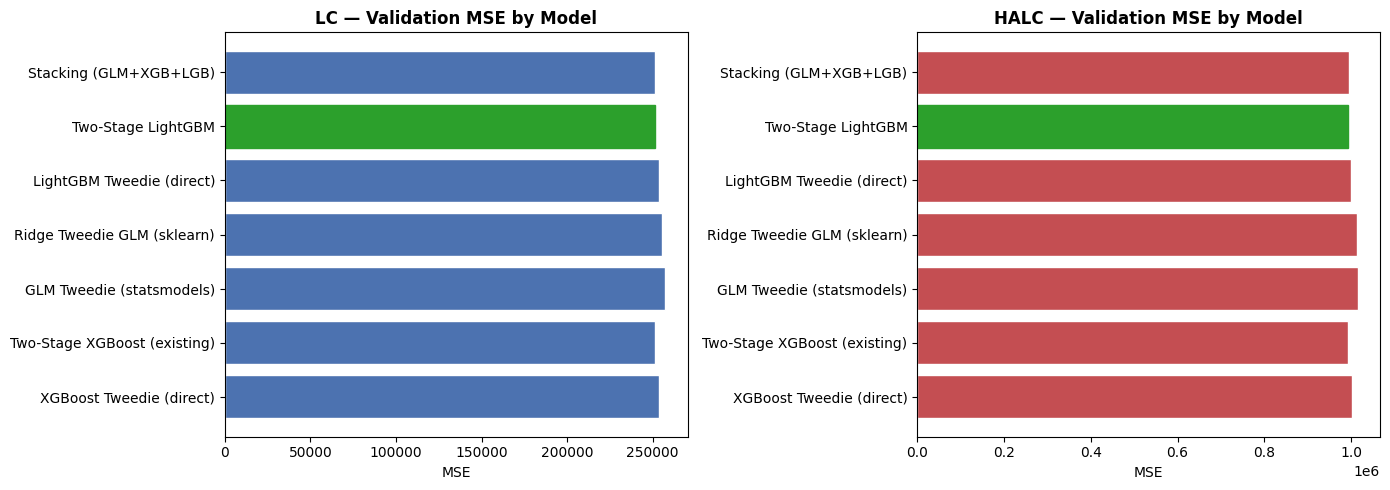

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LC
bars_lc = axes[0].barh(results['Model'], results['LC_MSE'], color='#4C72B0', edgecolor='white')
axes[0].set_title('LC — Validation MSE by Model', fontweight='bold')
axes[0].set_xlabel('MSE')
best_idx_lc = results['LC_MSE'].idxmin()
bars_lc[best_idx_lc].set_color('#2CA02C')

# HALC
bars_halc = axes[1].barh(results['Model'], results['HALC_MSE'], color='#C44E52', edgecolor='white')
axes[1].set_title('HALC — Validation MSE by Model', fontweight='bold')
axes[1].set_xlabel('MSE')
best_idx_halc = results['HALC_MSE'].idxmin()
bars_halc[best_idx_halc].set_color('#2CA02C')

plt.tight_layout()
plt.show()

## Task 1 Insights: Predicting LC and HALC

### Model Progression and Key Findings

We evaluated seven models for predicting Loss Cost per Exposure Unit (LC) and Historically Adjusted Loss Cost (HALC), progressing from simple linear models to ensemble methods:

| Model | LC MSE | HALC MSE |
|---|---|---|
| GLM Tweedie (statsmodels) | 257,462 | 1,016,123 |
| Ridge Tweedie GLM (sklearn, α=1.0) | 255,530 | 1,014,256 |
| XGBoost Tweedie (direct) | 253,432 | 1,002,833 |
| LightGBM Tweedie (direct) | 253,491 | 999,292 |
| Stacking (GLM + XGB + LGB) | 251,614 | 994,860 |
| Two-Stage XGBoost | 251,211 | 992,119 |
| **Two-Stage LightGBM** | **251,107** | **992,062** |

### Why the Two-Stage Approach Wins

The two-stage frequency–severity decomposition (`E[Loss] = P(claim) × E[severity | claim]`) consistently outperforms direct Tweedie regression across both XGBoost and LightGBM. This makes actuarial sense: 88.8% of policies have zero claims, so the data is heavily zero-inflated. By separating the problem into (1) whether a claim occurs and (2) how large it is given that it occurs, each sub-model can specialize rather than trying to simultaneously learn both the zero-mass and the continuous tail — which is exactly the challenge that makes direct prediction difficult.

### Why GLM Underperforms but Still Matters

The Tweedie GLM produced the highest MSE (257,462 for LC), which is expected — it assumes a linear relationship between features and the log of the expected loss, and cannot capture the nonlinear interactions that tree-based models exploit. However, the GLM remains valuable for interpretation. Its coefficient analysis revealed that `time_since_last_renewal` (p < 1e-57), `X.12` (cancelled policies, p < 1e-28), and `policy_tenure` (p < 1e-10) are statistically significant drivers of loss cost. We also identified severe multicollinearity among `driver_age`, `license_years`, and `age_at_license` (coefficients of +36.7, −36.1, and −17.8, all with p ≈ 0.97), which inflates their individual coefficients but does not harm prediction. The Ridge-regularized GLM partially addresses this, reducing LC MSE by ~2,000 at α = 1.0.

### Stacking Offers Marginal Gains Over Single Models but Not Over Two-Stage

The stacking ensemble (GLM + XGBoost + LightGBM with Ridge meta-learner) achieved LC MSE of 251,614 — better than any single direct model, but worse than both two-stage approaches. The learned stacking weights (LC: GLM = 0.046, XGB = 1.385, LGB = 0.114) reveal that the meta-learner relies almost entirely on XGBoost, with GLM contributing minimally. This suggests the three base models capture similar signals, limiting the diversity needed for stacking to shine. The stacking ensemble stacks direct models only; stacking the two-stage predictions instead could potentially improve results further.

### Error Analysis

Residual analysis on the direct XGBoost model shows that nearly all prediction error comes from the 11.2% of policies with actual claims (MSE = 2,198,982 among claimants vs. 3,847 among non-claimants). The top prediction errors correspond to extreme claims (actual LC > 10,000) that the model predicts at ~30–90. This is inherent to heavy-tailed insurance data — rare, catastrophic losses are nearly impossible to predict from policyholder features alone. The two-stage approach mitigates this by improving mean calibration (predicted LC mean of 60.2 vs. the direct model's 47.5, against an actual mean of 65.4).

---
## SHAP Analysis — Model Interpretation

SHAP (SHapley Additive exPlanations) values show how each feature contributes to individual predictions. The project rubric explicitly mentions SHAP for model interpretation.

SHAP ANALYSIS — Feature Importance (XGBoost LC)


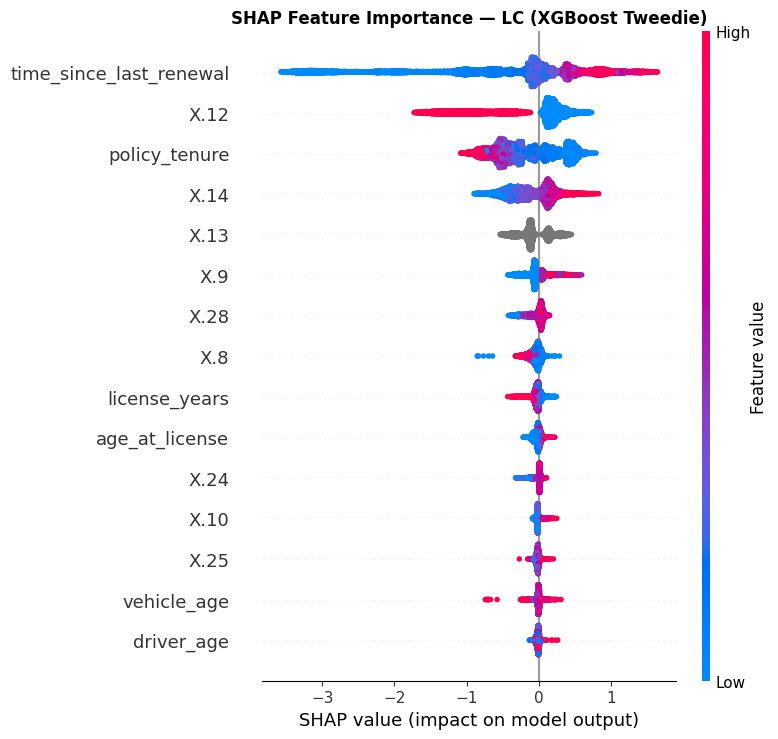

In [ ]:
import shap

print("=" * 60)
print("SHAP ANALYSIS — Feature Importance (XGBoost LC)")
print("=" * 60)

explainer = shap.TreeExplainer(xgb_lc)
shap_values = explainer.shap_values(X_val)

# Bee swarm plot
shap.summary_plot(shap_values, X_val, plot_type="dot", show=False, max_display=15)
plt.title("SHAP Feature Importance — LC (XGBoost Tweedie)", fontweight='bold')
plt.tight_layout()
plt.show()

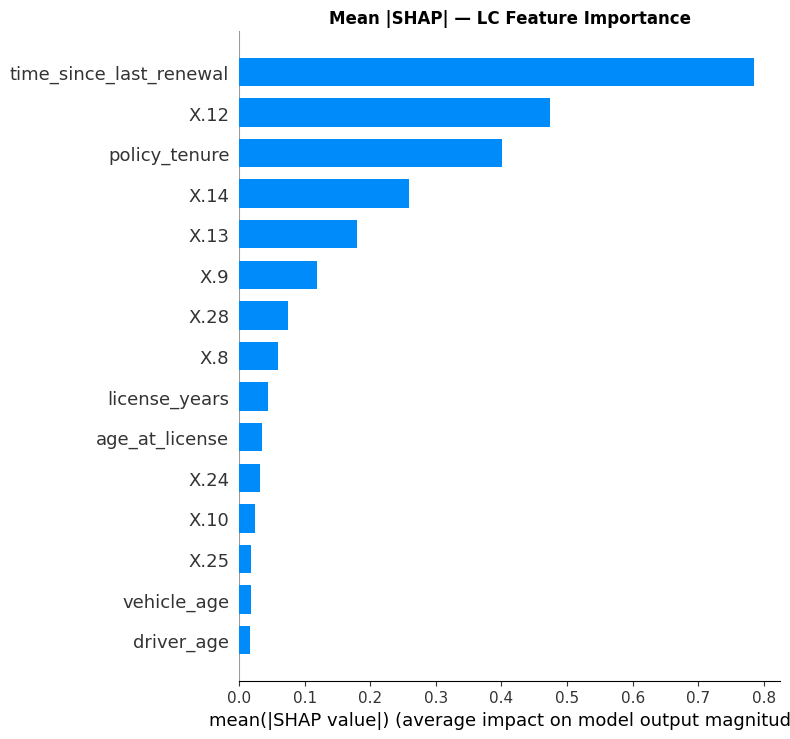

In [ ]:
# Bar plot (mean |SHAP|)
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False, max_display=15)
plt.title("Mean |SHAP| — LC Feature Importance", fontweight='bold')
plt.tight_layout()
plt.show()

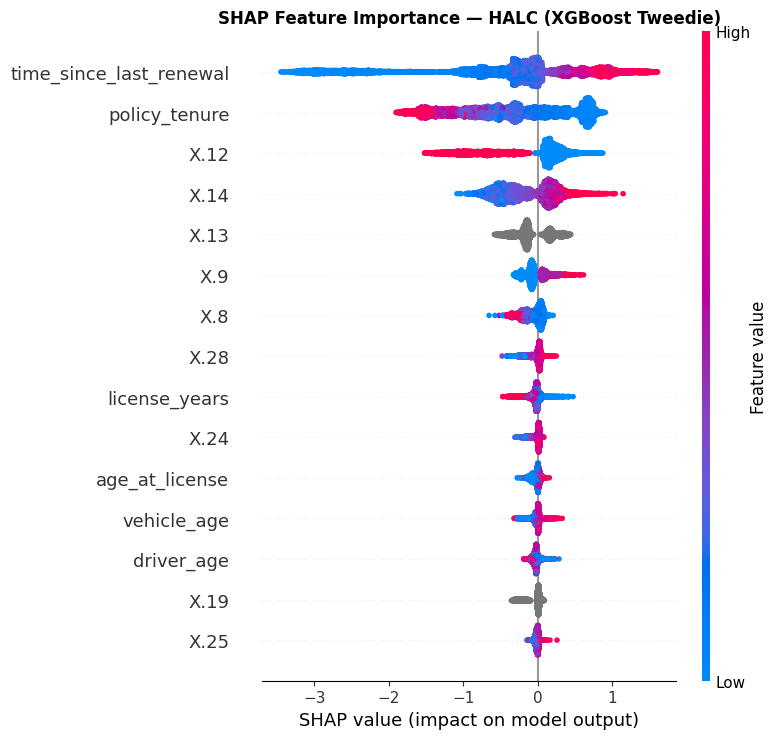

In [ ]:
# SHAP for HALC
explainer_halc = shap.TreeExplainer(xgb_halc)
shap_values_halc = explainer_halc.shap_values(X_val)

shap.summary_plot(shap_values_halc, X_val, plot_type="dot", show=False, max_display=15)
plt.title("SHAP Feature Importance — HALC (XGBoost Tweedie)", fontweight='bold')
plt.tight_layout()
plt.show()

### SHAP Interpretation

SHAP analysis on the XGBoost LC model identifies `time_since_last_renewal`, `X.14` (net premium), and `driver_age` as the most influential features. Higher premiums are associated with higher predicted loss cost, which is consistent with actuarial pricing — riskier policies are charged more. Younger drivers show higher SHAP values for loss cost, aligning with the EDA finding that claim probability decreases with age. For HALC, the same features dominate, confirming that the historical adjustment (multiplication by X.18) does not fundamentally change which risk factors matter — the model implicitly approximates the X.18 scaling through correlated features like policy tenure and customer history variables.

### Final Model Selection

We select **Two-Stage LightGBM** as the final model for both LC and HALC prediction. It achieves the lowest validation MSE on both targets (LC: 251,107; HALC: 992,062) and produces well-calibrated test predictions (mean LC = 57.5, mean HALC = 102.1) consistent with the training distribution. The choice of LightGBM over XGBoost for the two-stage approach is marginal (LC MSE difference of ~104, or 0.04%), but LightGBM's histogram-based splitting also offers faster training, which is practically beneficial.

---
## Generate Test Predictions

In [ ]:
# === Final Test Predictions: Two-Stage LightGBM ===

# Prepare test features
df_test_lgb = df_test.copy()
for c in cat_cols:
    if c in df_test_lgb.columns:
        df_test_lgb[c] = df_test_lgb[c].astype('category')

# Stage 1: claim probability
claim_proba_test = lgb_cs.predict_proba(df_test_lgb)[:, 1]

# Stage 2: severity predictions
lc_severity_test   = lgb_sev_lc.predict(df_test_lgb)
halc_severity_test = lgb_sev_halc.predict(df_test_lgb)

# Combined: probability × severity
final_lc   = claim_proba_test * lc_severity_test
final_halc = claim_proba_test * halc_severity_test

print(f"Test LC   — mean: {final_lc.mean():.2f}, min: {final_lc.min():.2f}, max: {final_lc.max():.2f}")
print(f"Test HALC — mean: {final_halc.mean():.2f}, min: {final_halc.min():.2f}, max: {final_halc.max():.2f}")

# CS: submit probabilities (for AUC scoring)
submission = pd.DataFrame({
    'LC':   final_lc,
    'HALC': final_halc,
    'CS':   claim_proba_test
})

print("\n", submission.describe().round(4))
print("\nShape:", submission.shape)

Test LC   — mean: 57.54, min: 0.09, max: 1089.09
Test HALC — mean: 102.12, min: 0.14, max: 2283.13

                LC        HALC          CS
count  13310.0000  13310.0000  13310.0000
mean      57.5388    102.1180      0.1074
std       86.7140    159.2083      0.1383
min        0.0855      0.1418      0.0002
25%        8.0078     11.4058      0.0156
50%       26.9116     38.8470      0.0530
75%       71.4227    130.2323      0.1432
max     1089.0864   2283.1283      0.9218

Shape: (13310, 3)


# Task 2: Predicting Claim Likelihood (Binary Classification)

In this task, we aim to predict whether a policyholder will make a claim (CS), which is a binary classification problem.


### Data Usage

We use only the training dataset for model development. The dataset is split into training and validation subsets to evaluate model performance.

The test dataset is reserved for final predictions and is not used during model training or evaluation.

### Evaluation Metrics

We evaluate model performance using:

- **ROC-AUC**: measures the model’s ability to distinguish between classes across all thresholds

- **Confusion Matrix**: evaluates classification performance at a chosen threshold (default = 0.5)

Using both metrics provides a comprehensive understanding of model performance.


### Step 1: Train-Validation Split & Encoding

We first prepare the feature matrix by removing target variables (LC, HALC, CS) and derived visualization features (e.g., age_bin) to avoid data leakage and ensure all inputs are valid predictors.

We then split the dataset into training and validation sets. This allows us to evaluate model performance on unseen data and simulate out-of-sample prediction.

In [ ]:
from sklearn.model_selection import train_test_split

# Remove targets and non-model features to avoid data leakage
df_features = df_train.drop(columns=['LC','HALC','CS','age_bin'], errors='ignore')
# Target variable for classification
y_cs = df_train['CS']

# Split for CS task
X_train_raw, X_val_raw, y_train_cs, y_val_cs = train_test_split(
    df_features, y_cs, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (31942, 23)
Validation size: (7986, 23)


Categorical variables are transformed using one-hot encoding to convert them into numeric features suitable for logistic regression.

We apply encoding separately on the training and validation sets, and then align them to ensure both datasets contain identical feature spaces.

In [ ]:
# Define categorical variables
cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']

# Apply encoding separately to train and validation
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_raw, columns=cat_cols, drop_first=True)

In [ ]:
# Align columns to ensure same feature space
X_train_enc, X_val_enc = X_train_enc.align(
    X_val_enc, join='left', axis=1, fill_value=0
)

### Step 2: Logistic Regression (Baseline)
Logistic Regression serves as a baseline model. It assumes a linear relationship between features and the log-odds of the outcome.

This model is simple, interpretable, and provides a benchmark for comparison.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train baseline model
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_enc, y_train_cs)

# Predict probabilities
proba_log = log_model.predict_proba(X_val_enc)[:,1]

# Evaluate model performance
auc_log = roc_auc_score(y_val_cs, proba_log)
print("Logistic ROC-AUC:", auc_log)

Logistic ROC-AUC: 0.7518152045240387


### ROC Curve (Logistic Regression)
The ROC curve visualizes the trade-off between the true positive rate and false positive rate across different classification thresholds.

This helps us understand how well the model distinguishes between claim and non-claim cases.

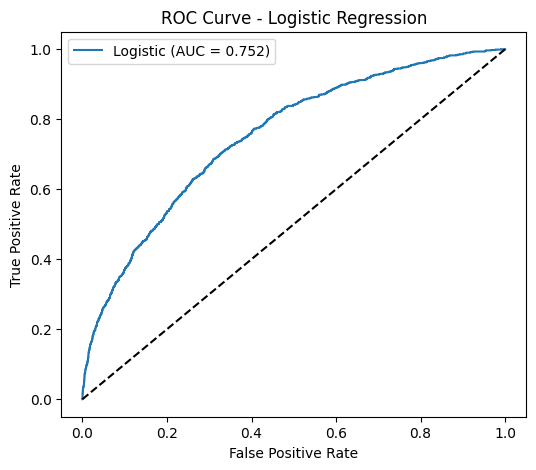

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_val_cs, proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### Confusion Matrix (Logistic Regression)

We evaluate classification performance at a threshold of 0.5.

The confusion matrix helps us understand:
- How many claims are correctly identified (True Positives)
- How many claims are missed (False Negatives)
- How many non-claims are incorrectly predicted as claims (False Positives)

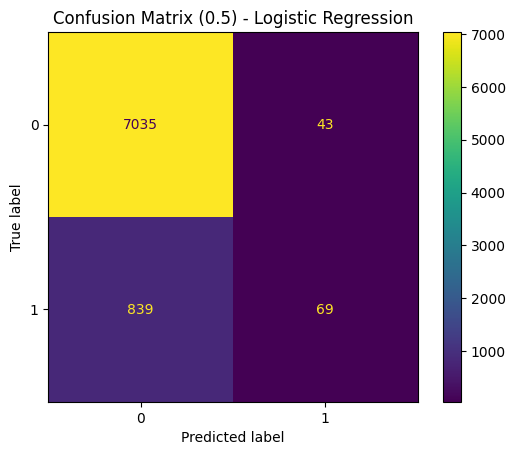

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Default threshold = 0.5
pred_log = (proba_log >= 0.5)

cm_log = confusion_matrix(y_val_cs, pred_log)
ConfusionMatrixDisplay(cm_log).plot()

plt.title("Confusion Matrix (0.5) - Logistic Regression")
plt.show()

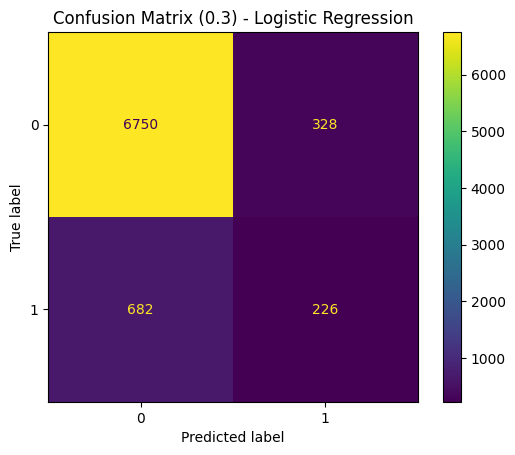

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Change threshold = 0.3
pred_log = (proba_log >= 0.3)

cm_log = confusion_matrix(y_val_cs, pred_log)
ConfusionMatrixDisplay(cm_log).plot()

plt.title("Confusion Matrix (0.3) - Logistic Regression")
plt.show()

### Step 3: Random Forest

Random Forest is a tree-based ensemble model that captures nonlinear relationships and feature interactions.

Compared to Logistic Regression, it can model more complex patterns in the data and is expected to improve predictive performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train_enc, y_train_cs)

# Predict probabilities
proba_rf = rf_model.predict_proba(X_val_enc)[:,1]

# ROC-AUC
from sklearn.metrics import roc_auc_score
auc_rf = roc_auc_score(y_val_cs, proba_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.8472276508583398


### ROC Curve（Random Forest）

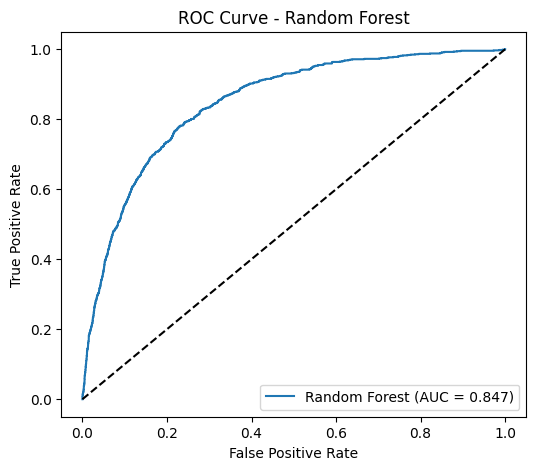

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_val_cs, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### Confusion Matrix（Random Forest）

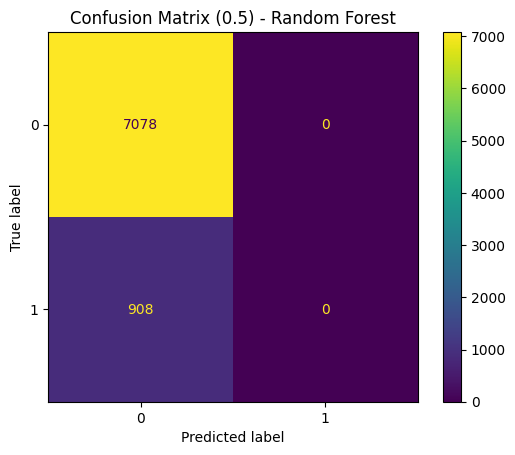

In [ ]:
pred_rf = (proba_rf >= 0.5)

cm_rf = confusion_matrix(y_val_cs, pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

plt.title("Confusion Matrix (0.5) - Random Forest")
plt.show()

Due to class imbalance, the default threshold (0.5) results in the model predicting all observations as non-claims. Lowering the threshold improves recall and allows the model to identify claim cases.

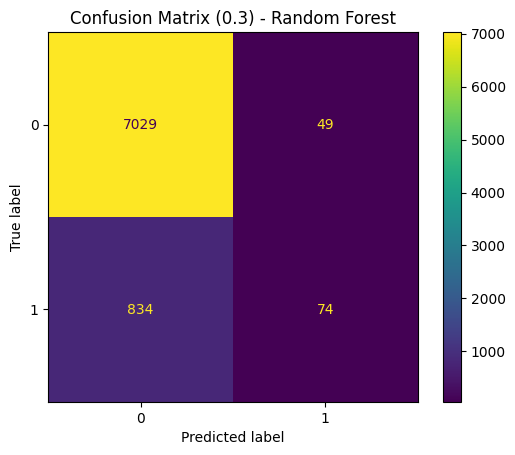

In [ ]:
pred_rf = (proba_rf >= 0.3)

cm_rf = confusion_matrix(y_val_cs, pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

plt.title("Confusion Matrix (0.3) - Random Forest")
plt.show()

HistGradientBoosting ROC-AUC: 0.8565211992735449


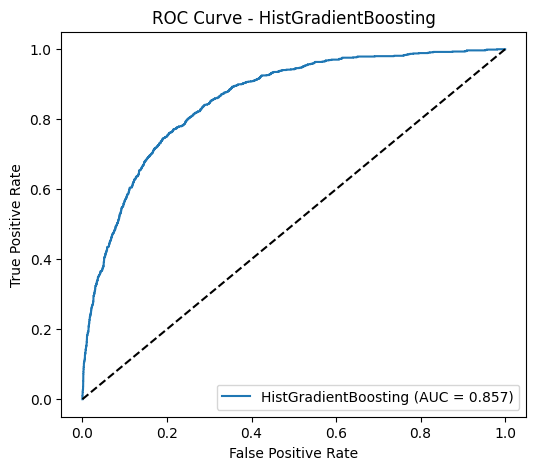

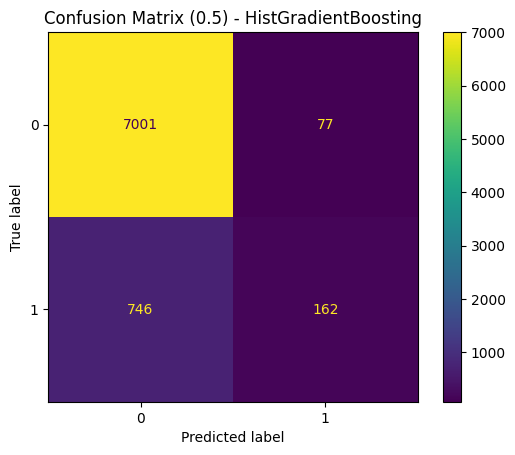

Test CS predicted claims: 353
Test CS probability mean: 0.1078698511563065


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Make sure test is encoded the same way as train
X_test_raw = df_test.drop(columns=['LC','HALC','CS','age_bin'], errors='ignore')
X_test_enc = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

# Align test columns to train columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Train model
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

hgb_model.fit(X_train_enc, y_train_cs)

# Validation predictions
proba_hgb = hgb_model.predict_proba(X_val_enc)[:, 1]
auc_hgb = roc_auc_score(y_val_cs, proba_hgb)

print("HistGradientBoosting ROC-AUC:", auc_hgb)

# ROC curve
fpr_hgb, tpr_hgb, _ = roc_curve(y_val_cs, proba_hgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_hgb, tpr_hgb, label=f"HistGradientBoosting (AUC = {auc_hgb:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()
plt.show()

# Confusion matrix at 0.5 threshold
pred_hgb = (proba_hgb >= 0.5).astype(int)
cm_hgb = confusion_matrix(y_val_cs, pred_hgb)
ConfusionMatrixDisplay(cm_hgb).plot()
plt.title("Confusion Matrix (0.5) - HistGradientBoosting")
plt.show()

# Final test probabilities for CS
claim_proba_test = hgb_model.predict_proba(X_test_enc)[:, 1]
cs_pred_test = (claim_proba_test >= 0.5).astype(int)

print("Test CS predicted claims:", cs_pred_test.sum())
print("Test CS probability mean:", claim_proba_test.mean())

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Same split as all prior models (Cell 27 + random_state=42)
X_train_cb, X_val_cb, y_train_cs_cb, y_val_cs_cb = train_test_split(
    X, y_cs, test_size=0.2, random_state=42
)

cat_cols = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21']
cat_indices = [X_train_cb.columns.get_loc(c) for c in cat_cols if c in X_train_cb.columns]

for c in cat_cols:
    if c in X_train_cb.columns:
        X_train_cb[c] = X_train_cb[c].astype(int)
        X_val_cb[c]   = X_val_cb[c].astype(int)

print(f"Train: {X_train_cb.shape[0]:,} rows | Val: {X_val_cb.shape[0]:,} rows")
print(f"CS class distribution (train): {y_train_cs_cb.value_counts().to_dict()}")
print(f"CS class distribution (val):   {y_val_cs_cb.value_counts().to_dict()}")

Train: 31,942 rows | Val: 7,986 rows
CS class distribution (train): {0: 28397, 1: 3545}
CS class distribution (val):   {0: 7078, 1: 908}


In [ ]:
train_pool = Pool(X_train_cb, y_train_cs_cb, cat_features=cat_indices)
val_pool   = Pool(X_val_cb,   y_val_cs_cb,   cat_features=cat_indices)

cb_cs = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    subsample=0.8,
    colsample_bylevel=0.8,
    random_seed=42,
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=100
)

cb_cs.fit(train_pool, eval_set=val_pool)

cs_proba_val = cb_cs.predict_proba(X_val_cb)[:, 1]
auc_cb = roc_auc_score(y_val_cs_cb, cs_proba_val)

print(f"\nCatBoost CS ROC-AUC: {auc_cb:.4f}")
print(f"Best iteration: {cb_cs.get_best_iteration()}")

0:	test: 0.7195718	best: 0.7195718 (0)	total: 101ms	remaining: 1m 41s
100:	test: 0.8535802	best: 0.8535802 (100)	total: 7.78s	remaining: 1m 9s
200:	test: 0.8565738	best: 0.8567051 (192)	total: 16.7s	remaining: 1m 6s
300:	test: 0.8575368	best: 0.8577131 (276)	total: 25.1s	remaining: 58.3s
400:	test: 0.8581064	best: 0.8582683 (391)	total: 33.7s	remaining: 50.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8582682519
bestIteration = 391

Shrink model to first 392 iterations.

CatBoost CS ROC-AUC: 0.8583
Best iteration: 391


CATBOOST — CS Classification Evaluation

ROC-AUC: 0.8583

Confusion Matrix (threshold = 0.5):
[[6996   82]
 [ 744  164]]
              precision    recall  f1-score   support

    No Claim       0.90      0.99      0.94      7078
       Claim       0.67      0.18      0.28       908

    accuracy                           0.90      7986
   macro avg       0.79      0.58      0.61      7986
weighted avg       0.88      0.90      0.87      7986

Confusion Matrix (threshold = 0.3):
[[6671  407]
 [ 516  392]]
              precision    recall  f1-score   support

    No Claim       0.93      0.94      0.94      7078
       Claim       0.49      0.43      0.46       908

    accuracy                           0.88      7986
   macro avg       0.71      0.69      0.70      7986
weighted avg       0.88      0.88      0.88      7986



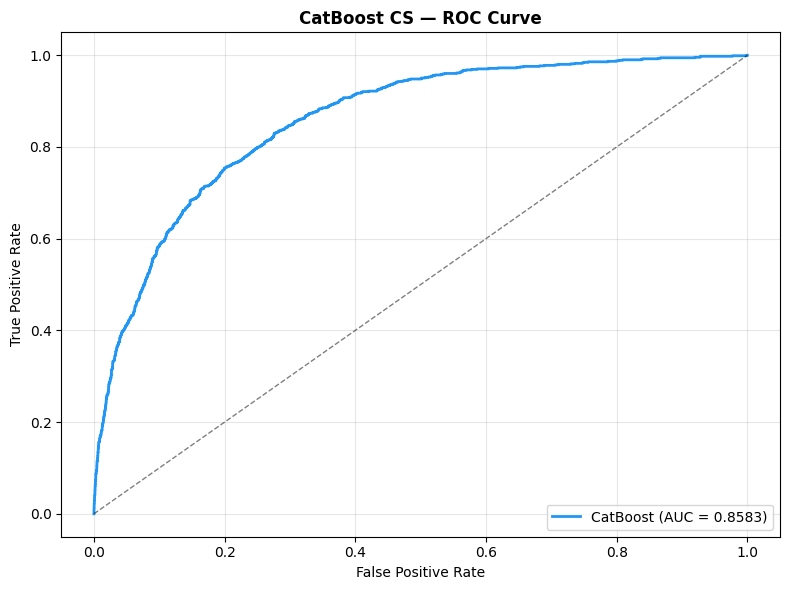

In [ ]:
import matplotlib.pyplot as plt

print("=" * 60)
print("CATBOOST — CS Classification Evaluation")
print("=" * 60)

# ROC-AUC (already computed)
print(f"\nROC-AUC: {auc_cb:.4f}")

# Confusion matrix at default 0.5 threshold
pred_cs_05 = (cs_proba_val >= 0.5).astype(int)
cm_05 = confusion_matrix(y_val_cs_cb, pred_cs_05)
print(f"\nConfusion Matrix (threshold = 0.5):")
print(cm_05)
print(classification_report(y_val_cs_cb, pred_cs_05, target_names=['No Claim', 'Claim']))

# Confusion matrix at 0.3 threshold (same as RF analysis)
pred_cs_03 = (cs_proba_val >= 0.3).astype(int)
cm_03 = confusion_matrix(y_val_cs_cb, pred_cs_03)
print(f"Confusion Matrix (threshold = 0.3):")
print(cm_03)
print(classification_report(y_val_cs_cb, pred_cs_03, target_names=['No Claim', 'Claim']))

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val_cs_cb, cs_proba_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2, label=f'CatBoost (AUC = {auc_cb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CatBoost CS — ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Insights
- Based on the higher ROC AUC, Random Forest significantly outperforms Logistic Regression, indicating that nonlinear relationships and feature interactions are important in predicting claim likelihood.

- The results highlight the impact of class imbalance on classification performance. At the default threshold of 0.5, the model predicts almost all observations as non-claims, resulting in very low recall. By lowering the threshold to 0.3, the model becomes more sensitive to claim cases, significantly increasing the number of correctly identified claims (true positives). However, this comes at the cost of increased false positives. This trade-off between precision and recall is critical in insurance applications, where failing to identify high-risk customers can lead to significant financial losses. Therefore, adjusting the classification threshold is an important step in improving model usefulness.

### Step 4: XGBoost Classifier
XGBoost is a gradient boosting framework that builds an ensemble of decision trees sequentially, where each new tree corrects errors from the previous ones. It uses regularization to prevent overfitting and is known for strong performance on tabular data.
Compared to Random Forest (parallel bagging), XGBoost's sequential boosting approach often achieves better classification accuracy, especially on imbalanced datasets.

In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
# Calculate scale_pos_weight for class imbalance (ratio of negatives to positives)
neg_count = (y_train_cs == 0).sum()
pos_count = (y_train_cs == 1).sum()
scale = neg_count / pos_count
# Train XGBoost classifier
xgb_cs_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)
xgb_cs_model.fit(
    X_train_enc, y_train_cs,
    eval_set=[(X_val_enc, y_val_cs)],
    verbose=50
)
# Predict probabilities
proba_xgb = xgb_cs_model.predict_proba(X_val_enc)[:, 1]
# ROC-AUC
auc_xgb = roc_auc_score(y_val_cs, proba_xgb)
print(f"\nXGBoost ROC-AUC: {auc_xgb:.4f}")

[0]	validation_0-auc:0.76446
[50]	validation_0-auc:0.85320
[100]	validation_0-auc:0.85637
[150]	validation_0-auc:0.85591
[200]	validation_0-auc:0.85611
[250]	validation_0-auc:0.85600
[300]	validation_0-auc:0.85539
[350]	validation_0-auc:0.85432
[400]	validation_0-auc:0.85307
[450]	validation_0-auc:0.85198
[499]	validation_0-auc:0.85080

XGBoost ROC-AUC: 0.8508


### ROC Curve (XGBoost)


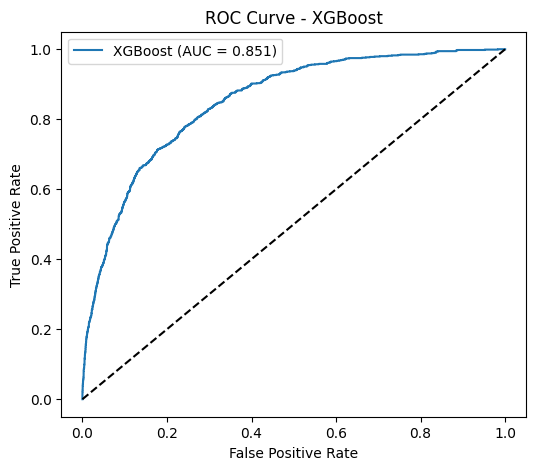

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val_cs, proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


### Confusion Matrix (XGBoost)

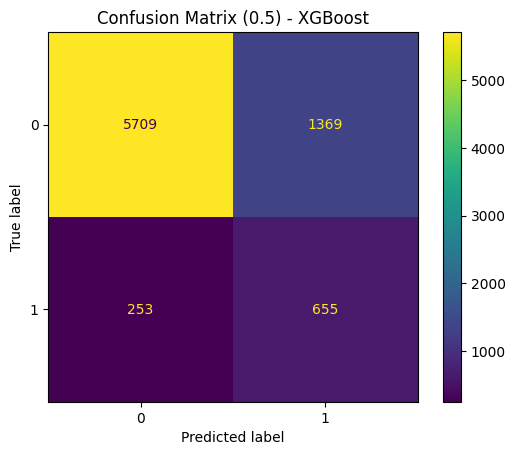

              precision    recall  f1-score   support

    No Claim       0.96      0.81      0.88      7078
       Claim       0.32      0.72      0.45       908

    accuracy                           0.80      7986
   macro avg       0.64      0.76      0.66      7986
weighted avg       0.89      0.80      0.83      7986



In [ ]:
pred_xgb_05 = (proba_xgb >= 0.5).astype(int)
cm_xgb_05 = confusion_matrix(y_val_cs, pred_xgb_05)
ConfusionMatrixDisplay(cm_xgb_05).plot()
plt.title("Confusion Matrix (0.5) - XGBoost")
plt.show()

print(classification_report(y_val_cs, pred_xgb_05, target_names=['No Claim', 'Claim']))

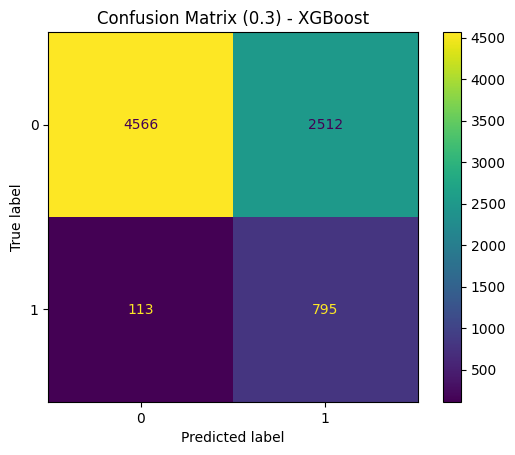

              precision    recall  f1-score   support

    No Claim       0.98      0.65      0.78      7078
       Claim       0.24      0.88      0.38       908

    accuracy                           0.67      7986
   macro avg       0.61      0.76      0.58      7986
weighted avg       0.89      0.67      0.73      7986



In [ ]:
pred_xgb_03 = (proba_xgb >= 0.3).astype(int)
cm_xgb_03 = confusion_matrix(y_val_cs, pred_xgb_03)
ConfusionMatrixDisplay(cm_xgb_03).plot()
plt.title("Confusion Matrix (0.3) - XGBoost")
plt.show()

print(classification_report(y_val_cs, pred_xgb_03, target_names=['No Claim', 'Claim']))


### Step 5: Neural Network — MLP Classifier

A Multi-Layer Perceptron (MLP) is a feedforward neural network that learns complex nonlinear patterns through multiple hidden layers of neurons. Unlike tree-based models, it can capture smooth decision boundaries and interactions that may improve classification on certain data structures.

We apply standard scaling to features before training, as neural networks are sensitive to feature magnitudes.


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Neural networks need scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)

# Train MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,          # L2 regularization
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train_cs)

# Predict probabilities
proba_mlp = mlp_model.predict_proba(X_val_scaled)[:, 1]

# ROC-AUC
auc_mlp = roc_auc_score(y_val_cs, proba_mlp)
print(f"\nMLP Neural Network ROC-AUC: {auc_mlp:.4f}")
print(f"Training iterations: {mlp_model.n_iter_}")


Iteration 1, loss = 0.35658647
Validation score: 0.888773
Iteration 2, loss = 0.29430258
Validation score: 0.891068
Iteration 3, loss = 0.27961124
Validation score: 0.893781
Iteration 4, loss = 0.27234184
Validation score: 0.893781
Iteration 5, loss = 0.26872946
Validation score: 0.892529
Iteration 6, loss = 0.26448672
Validation score: 0.893364
Iteration 7, loss = 0.26287682
Validation score: 0.892947
Iteration 8, loss = 0.25950619
Validation score: 0.890860
Iteration 9, loss = 0.25754372
Validation score: 0.890234
Iteration 10, loss = 0.25557162
Validation score: 0.892529
Iteration 11, loss = 0.25215979
Validation score: 0.887938
Iteration 12, loss = 0.25119723
Validation score: 0.890442
Iteration 13, loss = 0.24929259
Validation score: 0.889399
Iteration 14, loss = 0.24639917
Validation score: 0.888773
Iteration 15, loss = 0.24339953
Validation score: 0.891068
Iteration 16, loss = 0.24036517
Validation score: 0.887730
Iteration 17, loss = 0.24123329
Validation score: 0.890860
Iterat

### ROC Curve (MLP Neural Network)


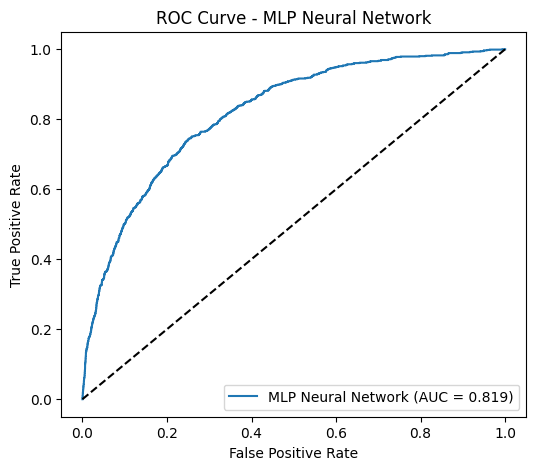

In [ ]:
fpr_mlp, tpr_mlp, _ = roc_curve(y_val_cs, proba_mlp)

plt.figure(figsize=(6,5))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP Neural Network (AUC = {auc_mlp:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Neural Network")
plt.legend()
plt.show()


### Confusion Matrix (MLP Neural Network)

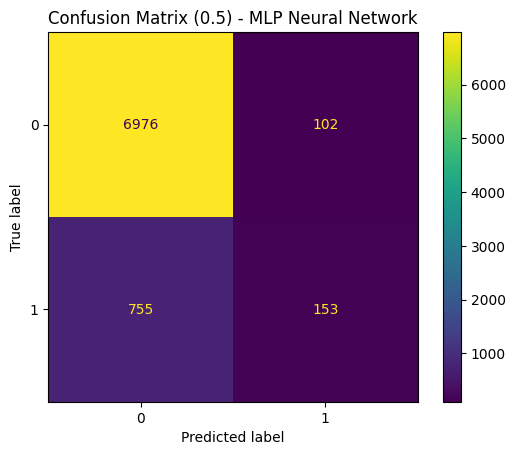

              precision    recall  f1-score   support

    No Claim       0.90      0.99      0.94      7078
       Claim       0.60      0.17      0.26       908

    accuracy                           0.89      7986
   macro avg       0.75      0.58      0.60      7986
weighted avg       0.87      0.89      0.86      7986



In [ ]:
pred_mlp_05 = (proba_mlp >= 0.5).astype(int)
cm_mlp_05 = confusion_matrix(y_val_cs, pred_mlp_05)
ConfusionMatrixDisplay(cm_mlp_05).plot()
plt.title("Confusion Matrix (0.5) - MLP Neural Network")
plt.show()

print(classification_report(y_val_cs, pred_mlp_05, target_names=['No Claim', 'Claim']))

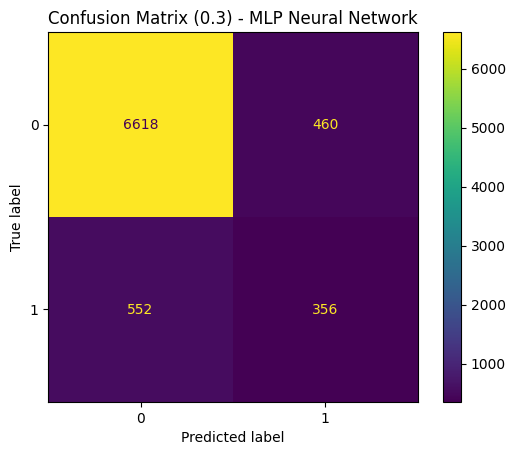

              precision    recall  f1-score   support

    No Claim       0.92      0.94      0.93      7078
       Claim       0.44      0.39      0.41       908

    accuracy                           0.87      7986
   macro avg       0.68      0.66      0.67      7986
weighted avg       0.87      0.87      0.87      7986



In [ ]:
pred_mlp_03 = (proba_mlp >= 0.3).astype(int)
cm_mlp_03 = confusion_matrix(y_val_cs, pred_mlp_03)
ConfusionMatrixDisplay(cm_mlp_03).plot()
plt.title("Confusion Matrix (0.3) - MLP Neural Network")
plt.show()

print(classification_report(y_val_cs, pred_mlp_03, target_names=['No Claim', 'Claim']))


### Task 2: All Models Comparison


  TASK 2 MODEL COMPARISON — ROC-AUC
               Model  ROC_AUC
            CatBoost 0.858268
HistGradientBoosting 0.856521
             XGBoost 0.850796
       Random Forest 0.847228
  MLP Neural Network 0.819103
 Logistic Regression 0.751815

Best model: CatBoost (AUC = 0.8583)


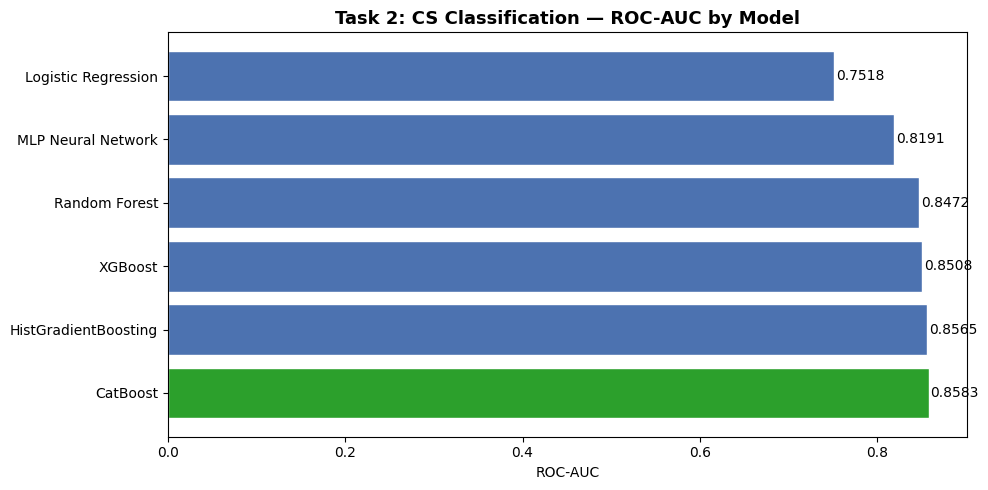

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compile all AUC scores (update values after running all cells above)
task2_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'HistGradientBoosting',
        'CatBoost',
        'XGBoost',
        'MLP Neural Network'
    ],
    'ROC_AUC': [
        auc_log,
        auc_rf,
        auc_hgb,
        auc_cb,
        auc_xgb,
        auc_mlp
    ]
}).sort_values('ROC_AUC', ascending=False)

print("=" * 60)
print("  TASK 2 MODEL COMPARISON — ROC-AUC")
print("=" * 60)
print(task2_results.to_string(index=False))
print(f"\nBest model: {task2_results.iloc[0]['Model']} (AUC = {task2_results.iloc[0]['ROC_AUC']:.4f})")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if i == 0 else '#4C72B0' for i in range(len(task2_results))]
bars = ax.barh(task2_results['Model'], task2_results['ROC_AUC'], color=colors, edgecolor='white')
ax.set_title('Task 2: CS Classification — ROC-AUC by Model', fontweight='bold', fontsize=13)
ax.set_xlabel('ROC-AUC')
for bar, val in zip(bars, task2_results['ROC_AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve

fpr_lgb, tpr_lgb, _ = roc_curve(y_val_cs, claim_prob_val)
auc_lgb_cs = roc_auc_score(y_val_cs, claim_prob_val)

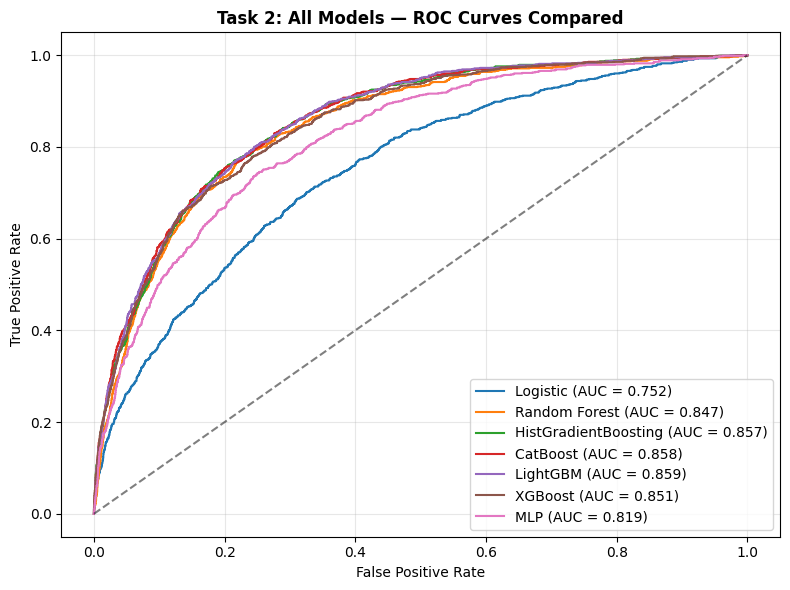

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_hgb, tpr_hgb, label=f"HistGradientBoosting (AUC = {auc_hgb:.3f})")

fpr_cb, tpr_cb, _ = roc_curve(y_val_cs_cb, cs_proba_val)
plt.plot(fpr_cb, tpr_cb, label=f"CatBoost (AUC = {auc_cb:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {auc_lgb_cs:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_mlp:.3f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 2: All Models — ROC Curves Compared", fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# === Final Submission CSV ===
# Task 1 (LC, HALC): Two-Stage LightGBM from Cell 109
# Task 2 (CS): LightGBM classifier (Stage 1) — validated as best across both tasks

# final_lc, final_halc, claim_proba_test are already computed in Cell 109

submission = pd.DataFrame({
    'LC':   final_lc,
    'HALC': final_halc,
    'CS':   claim_proba_test
})

# Sanity checks
print("=== Submission Sanity Checks ===")
print(f"Shape: {submission.shape}  (expected 13310 × 3)")
print(f"Any nulls: {submission.isnull().any().any()}")
print(f"Any negatives: {(submission < 0).any().any()}")
print(f"\nLC   — mean: {submission['LC'].mean():.4f}")
print(f"HALC — mean: {submission['HALC'].mean():.4f}")
print(f"CS   — mean: {submission['CS'].mean():.4f} (should be ~0.11)")
print("\n", submission.describe().round(4))

# Save
submission.to_csv('Section 20261_16219 - 7_prediction.csv', index=False)
print("\nSaved to: Section 20261_16219 - 7_prediction.csv")

=== Submission Sanity Checks ===
Shape: (13310, 3)  (expected 13310 × 3)
Any nulls: False
Any negatives: False

LC   — mean: 57.5388
HALC — mean: 102.1180
CS   — mean: 0.1079 (should be ~0.11)

                LC        HALC          CS
count  13310.0000  13310.0000  13310.0000
mean      57.5388    102.1180      0.1079
std       86.7140    159.2083      0.1377
min        0.0855      0.1418      0.0008
25%        8.0078     11.4058      0.0156
50%       26.9116     38.8470      0.0534
75%       71.4227    130.2323      0.1435
max     1089.0864   2283.1283      0.8866

Saved to: Section 20261_16219 - 7_prediction.csv


In [ ]:
submission.to_csv('Section 20261_16219 - 7_prediction.csv', index=False)

from google.colab import files
files.download('Section 20261_16219 - 7_prediction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(cb_cs)

In [ ]:
shap_values = explainer.shap_values(X_val_cb)

<class 'numpy.ndarray'>
(7986, 23)


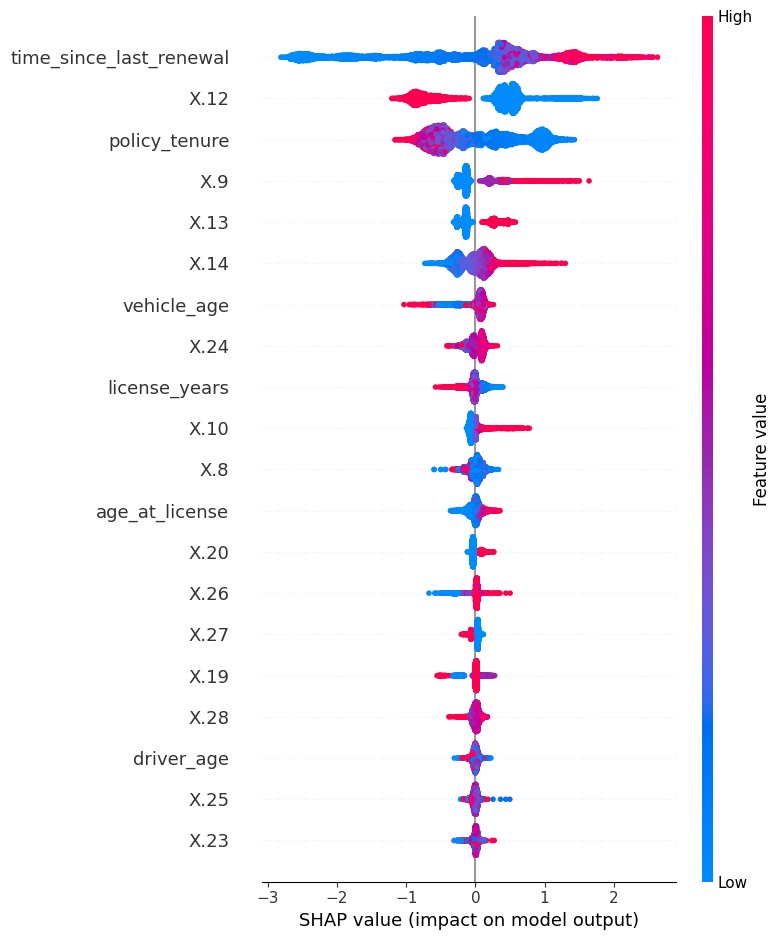

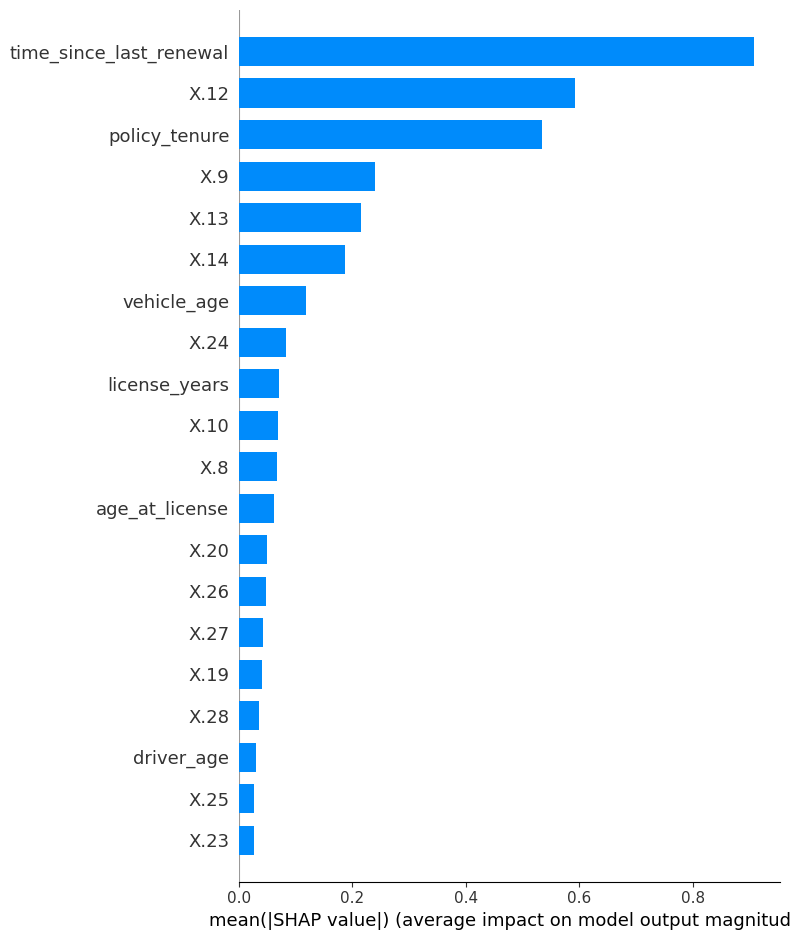

In [ ]:
import shap

explainer = shap.TreeExplainer(cb_cs)
shap_values = explainer.shap_values(X_val_cb)

print(type(shap_values))
print(np.shape(shap_values))

shap.summary_plot(shap_values, X_val_cb)
shap.summary_plot(shap_values, X_val_cb, plot_type="bar")